In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from reporteLib import (
    preparar_encuesta,
    evaluar_supuestos_parametricos,
    normalidad_y_levene_por_grupos,
    pruebas_no_parametricas,
    spearman,
    kruskal_wallis,
    chi_cuadrada,
    mann_whitney_pares,
    wilcoxon_pareado,
    ajuste_gamma_agrupada,
    regresion_cuantil,
    resumen_grupos,
    grafica_barras,
    grafica_conteos,
    grafica_resumen_grupos,
    grafica_dispersion,
    grafica_boxplot_por_categoria,
    screening_masivo,
)


pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

from pathlib import Path

BASE_DIR = Path.cwd()
GRAFICAS_DIR = BASE_DIR / "graficas"
SCREENINGS_DIR = BASE_DIR / "screenings"

GRAFICAS_DIR.mkdir(parents=True, exist_ok=True)
SCREENINGS_DIR.mkdir(parents=True, exist_ok=True)

def guardar_y_mostrar(pregunta, numero, dpi=300):
    """Guarda la figura actual en PNG y después la muestra."""
    ruta = GRAFICAS_DIR / f"{pregunta}_grafica_{numero:02d}.png"
    fig = plt.gcf()
    fig.savefig(
        ruta,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Gráfica guardada: {ruta}")
    plt.show()

def guardar_screening(tabla, pregunta):
    """Guarda el screening completo en Excel, incluyendo attrs en una hoja metadata."""
    ruta = SCREENINGS_DIR / f"{pregunta}_screening.xlsx"

    with pd.ExcelWriter(ruta, engine="openpyxl") as writer:
        tabla.to_excel(writer, sheet_name="screening", index=False)

        if getattr(tabla, "attrs", None):
            metadata = pd.DataFrame(
                {
                    "atributo": list(tabla.attrs.keys()),
                    "valor": [repr(v) for v in tabla.attrs.values()],
                }
            )
            metadata.to_excel(writer, sheet_name="metadata", index=False)

    print(f"Screening guardado: {ruta}")

print(f"Carpeta de gráficas: {GRAFICAS_DIR.resolve()}")
print(f"Carpeta de screenings: {SCREENINGS_DIR.resolve()}")

# ---

df = pd.read_excel("BasedeDatos.xlsx")


Carpeta de gráficas: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas
Carpeta de screenings: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings


In [2]:
for i in df.columns:
    print(i)

Transecto
Ageb Manzana
Sexo
Edad
Escolaridad
¿Cuántos años tiene viviendo en este lugar?
¿Cuántas personas viven en este hogar?
¿Cuántas de esas personas….? | Tienen 18 años o más
¿Cuántas de esas personas….? | Aportan económicamente al hogar
¿Cuántas de esas personas….? | Cuentan con un trabajo remunerado que requiera más de 20 horas a la semana
¿Alguna de estas personas tiene…?  | Disfunción motriz
¿Alguna de estas personas tiene…?  | Debilidad visual
¿Alguna de estas personas tiene…?  | Auditiva
¿Alguna de estas personas tiene…?  | Autismo
¿Durante la pandemia, existió la necesidad de que una persona de la familia tuviera que irse a vivir a otro lado o venir a vivir a esta casa por causa de la pandemia? 
La vivienda es… 
¿Cómo describe al estado de mantenimiento de esta vivienda? 
Número de pisos sobre el nivel de banqueta 
¿Si es vivienda vertical, en qué piso se encuentra? 
De las siguientes opciones, ¿Cuál es el tipo de material de la azotea de esta vivienda? 
De las siguientes o

___


# 1


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P01_grafica_01.png


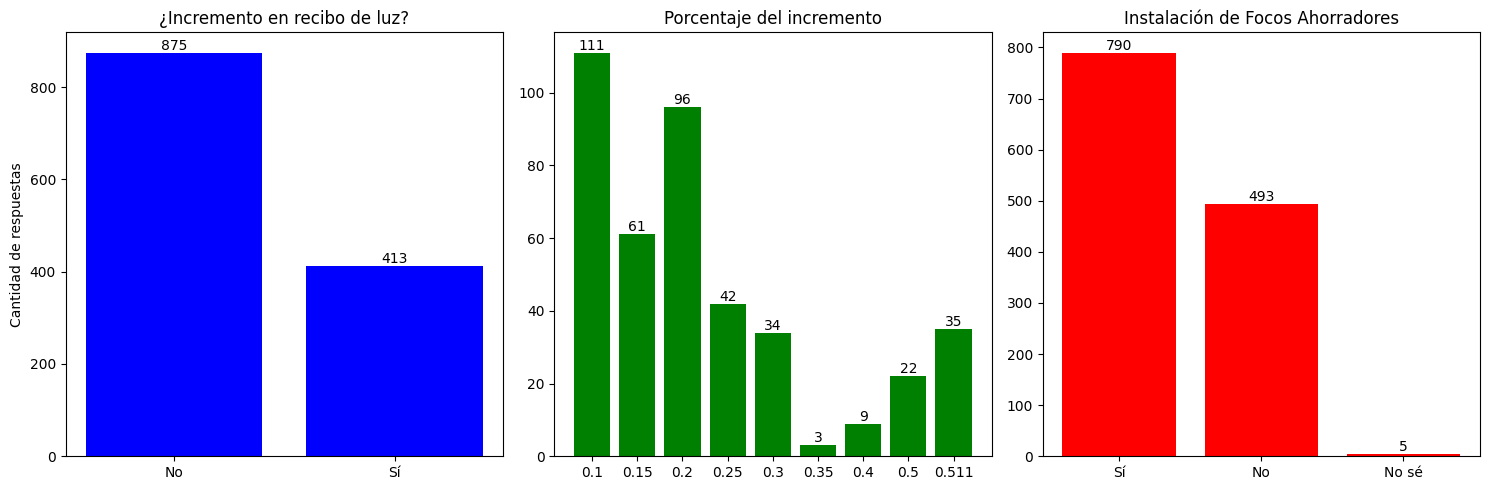

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P01_grafica_02.png


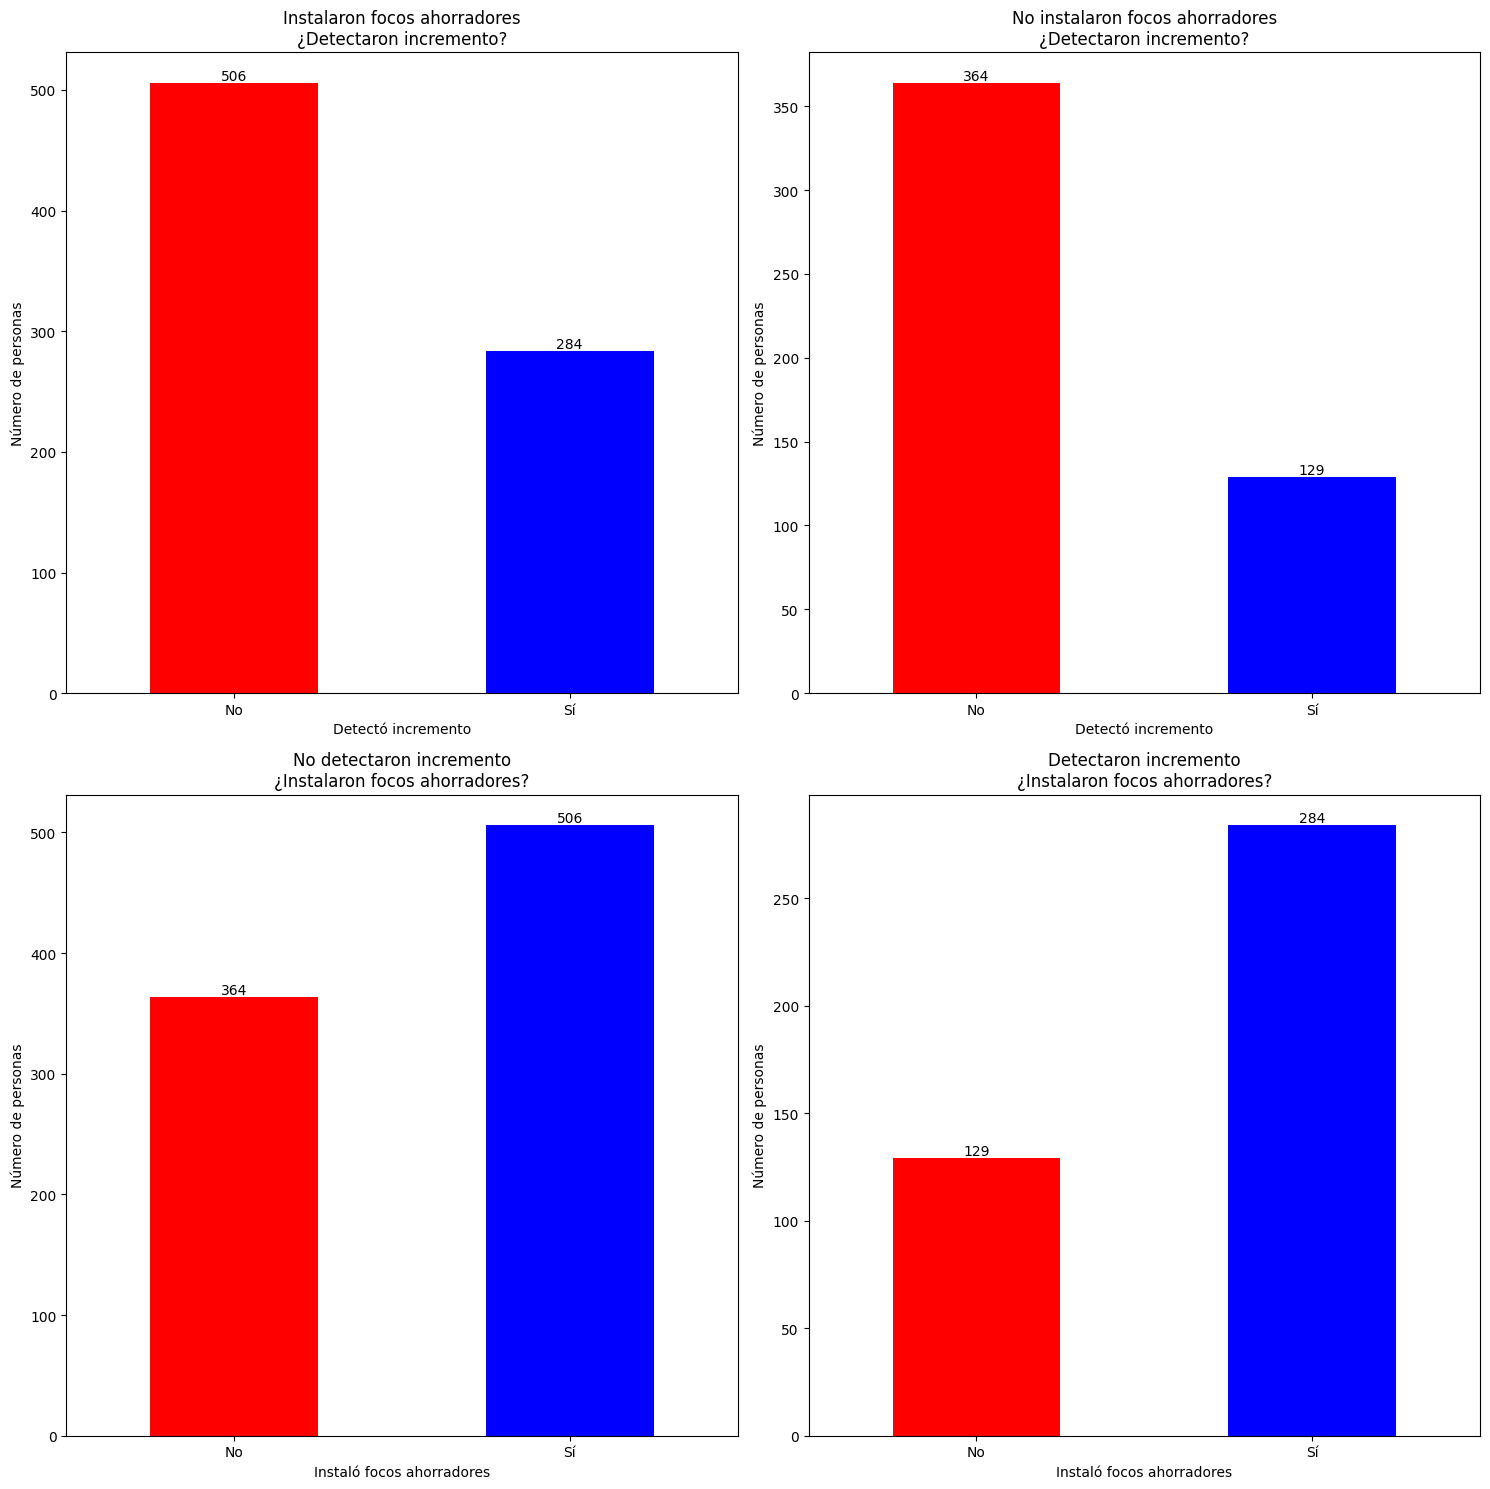

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P01_grafica_03.png


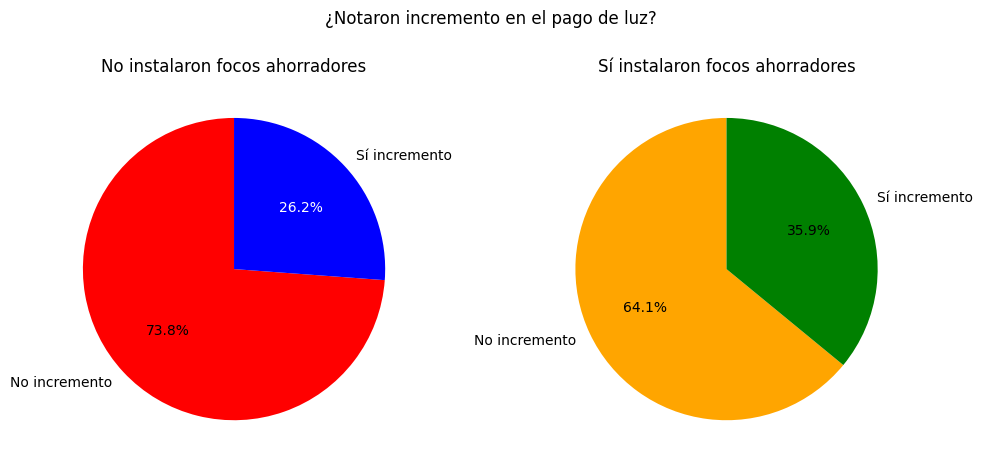

In [3]:
df["¿Detectó algún incremento en el pago del servicio de luz? "].value_counts()


df["¿De cuánto fue ese incremento aproximadamente?"]
df["¿De cuánto fue ese incremento aproximadamente?"] = pd.to_numeric(
    df["¿De cuánto fue ese incremento aproximadamente?"].map(
        lambda v: 0.511 if v == "Más del 51%" else v
    ), errors="coerce"
)
df["¿De cuánto fue ese incremento aproximadamente?"].value_counts()


df["Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Focos ahorradores"].value_counts()


p1v1=df["¿Detectó algún incremento en el pago del servicio de luz? "].value_counts()
p1v2=df["¿De cuánto fue ese incremento aproximadamente?"].value_counts()
p1v3=df["Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Focos ahorradores"].value_counts()

fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(15, 5))

bar1=ax1.bar(p1v1.index, p1v1.values, color="blue")
ax1.bar_label(bar1)
ax1.set_title("¿Incremento en recibo de luz?")
ax1.set_ylabel("Cantidad de respuestas")

p1v2 = p1v2.sort_index()
p1v2.index_str = p1v2.index.astype(str) 
bar2=ax2.bar(p1v2.index_str , p1v2.values, color="green")
ax2.bar_label(bar2)
ax2.set_title("Porcentaje del incremento")

bar3=ax3.bar(p1v3.index, p1v3.values, color="red")
ax3.bar_label(bar3)
ax3.set_title("Instalación de Focos Ahorradores")

plt.tight_layout()
guardar_y_mostrar("P01", 1)


p1 = df[["¿Detectó algún incremento en el pago del servicio de luz? ","¿De cuánto fue ese incremento aproximadamente?","Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Focos ahorradores"]].copy()
p1 = p1[(p1[p1.columns[2]] != "No sé")]
p1.groupby([p1.columns[2], p1.columns[0]]).size().unstack(fill_value=0)


p1r = p1.groupby([p1.columns[2], p1.columns[0]]).size().unstack(fill_value=0)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 15))

p1r.loc["Sí"].plot(kind="bar", ax=ax1, color=["red", "blue"])
ax1.set_title("Instalaron focos ahorradores\n¿Detectaron incremento?")
ax1.set_xlabel("Detectó incremento")
ax1.set_ylabel("Número de personas")
ax1.tick_params(axis='x', rotation=0)
for contenedor in ax1.containers:
    ax1.bar_label(contenedor)

p1r.loc["No"].plot(kind="bar", ax=ax2, color=["red", "blue"])
ax2.set_title("No instalaron focos ahorradores\n¿Detectaron incremento?")
ax2.set_xlabel("Detectó incremento")
ax2.set_ylabel("Número de personas")
ax2.tick_params(axis='x', rotation=0)
for contenedor in ax2.containers:
    ax2.bar_label(contenedor)

p1r["No"].plot(kind="bar", ax=ax3, color=["red", "blue"])
ax3.set_title("No detectaron incremento\n¿Instalaron focos ahorradores?")
ax3.set_xlabel("Instaló focos ahorradores")
ax3.set_ylabel("Número de personas")
ax3.tick_params(axis='x', rotation=0)
for contenedor in ax3.containers:
    ax3.bar_label(contenedor)

p1r["Sí"].plot(kind="bar", ax=ax4, color=["red", "blue"])
ax4.set_title("Detectaron incremento\n¿Instalaron focos ahorradores?")
ax4.set_xlabel("Instaló focos ahorradores")
ax4.set_ylabel("Número de personas")
ax4.tick_params(axis='x', rotation=0)
for contenedor in ax4.containers:
    ax4.bar_label(contenedor)

plt.tight_layout()
guardar_y_mostrar("P01", 2)


p1r


x11 = p1r.iloc[0, 0]
x12 = p1r.iloc[0, 1]
x21 = p1r.iloc[1, 0]
x22 = p1r.iloc[1, 1]

tot_fila0 = x11 + x12
tot_fila1 = x21 + x22

pct11 = x11 / tot_fila0
pct12 = x12 / tot_fila0
pct21 = x21 / tot_fila1
pct22 = x22 / tot_fila1

pct11, pct12, pct21, pct22


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

wedges1, texts1, autotexts1 = ax1.pie(
    [pct11, pct12],
    labels=["No incremento", "Sí incremento"],
    colors=["red", "blue"],
    autopct="%1.1f%%",
    startangle=90
)
autotexts1[1].set_color("white") 
ax1.set_title("No instalaron focos ahorradores")

wedges2, texts2, autotexts2 = ax2.pie(
    [pct21, pct22],
    labels=["No incremento", "Sí incremento"],
    colors=["orange", "green"],
    autopct="%1.1f%%",
    startangle=90
)
ax2.set_title("Sí instalaron focos ahorradores")

plt.suptitle("¿Notaron incremento en el pago de luz?")
plt.tight_layout()
guardar_y_mostrar("P01", 3)

# 2


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P02_grafica_01.png


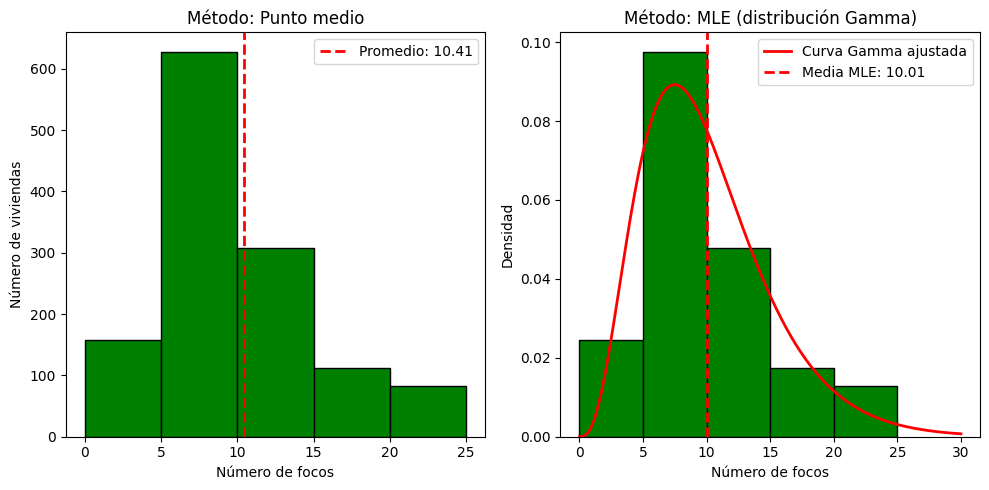

In [4]:
p2=df["¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?"].copy()
p2.value_counts()


p2 = p2[p2 != "No sé"]
valor={
    "5 o menos focos":3,
    "Entre 6 y 10 focos":8,
    "Entre 11 y 15 focos":13,
    "Entre 16 y 20 focos":18,
    "21 focos o más":23,
}

p2v=p2.map(valor)
p2v.value_counts()


p2r = p2v.mean()

bins = {
    "5 o menos focos": (0.001, 5),
    "Entre 6 y 10 focos": (5, 10),
    "Entre 11 y 15 focos": (10, 15),
    "Entre 16 y 20 focos": (15, 20),
    "21 focos o más": (20, np.inf),
}

gamma_p2 = ajuste_gamma_agrupada(p2, bins)
a_mle = gamma_p2["shape"]
scale_mle = gamma_p2["scale"]
media_gamma = gamma_p2["media"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.hist(p2v, bins=[0, 5, 10, 15, 20, 25], edgecolor="black", color="green")
ax1.axvline(p2r, linestyle="--", linewidth=2, label=f"Promedio: {p2r:.2f}", color="red")
ax1.set_xlabel("Número de focos")
ax1.set_ylabel("Número de viviendas")
ax1.set_title("Método: Punto medio")
ax1.legend()

x = np.linspace(0.01, 30, 300)
y = stats.gamma.pdf(x, a_mle, scale=scale_mle)
ax2.hist(p2v, bins=[0, 5, 10, 15, 20, 25], edgecolor="black", density=True, color="green")
ax2.plot(x, y, linewidth=2, label="Curva Gamma ajustada",color="red")
ax2.axvline(media_gamma, linestyle="--", linewidth=2, label=f"Media MLE: {media_gamma:.2f}",color="red")
ax2.set_xlabel("Número de focos")
ax2.set_ylabel("Densidad")
ax2.set_title("Método: MLE (distribución Gamma)")
ax2.legend()
plt.tight_layout()
guardar_y_mostrar("P02", 1)

# 3


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P03_grafica_01.png


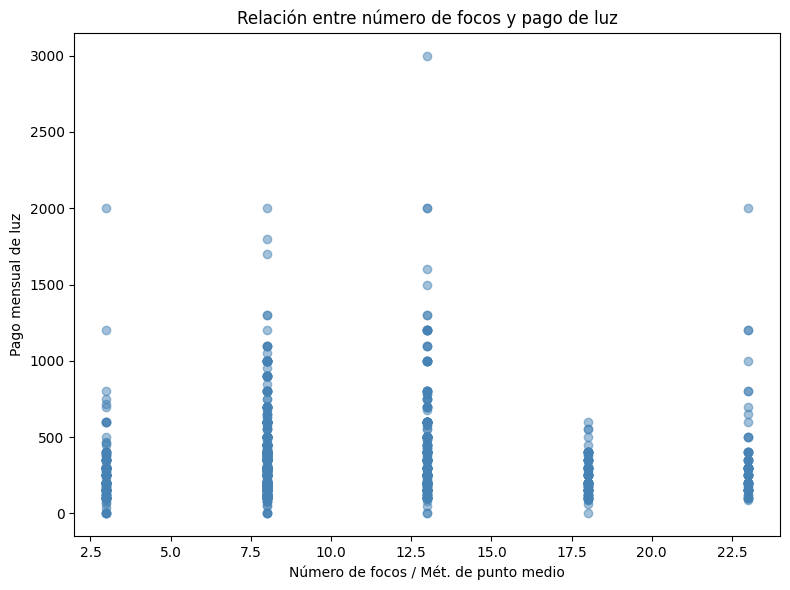

{'spearman': {'prueba': 'Spearman',
  'n': 1285,
  'estadistico': 0.007830708038104598,
  'p_valor': 0.7791417179831062,
  'effect_size': 0.007830708038104598,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'No'},
 'distance_correlation': 0.13189596464062586,
 'mutual_information': 0.03733733586818033}

{'prueba': 'Kruskal-Wallis',
 'n': 1285,
 'estadistico': 77.76602724800064,
 'p_valor': 5.177376047770662e-16,
 'effect_size': 0.06056544178193196,
 'magnitud': 'Moderado',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'Sí',
 'grupo_min_n': 82}

¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?
21 focos o más         250.0
5 o menos focos        250.0
Entre 11 y 15 focos    350.0
Entre 16 y 20 focos    200.0
Entre 6 y 10 focos     300.0
Name: ¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Luz, dtype: float64

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P03_grafica_02.png


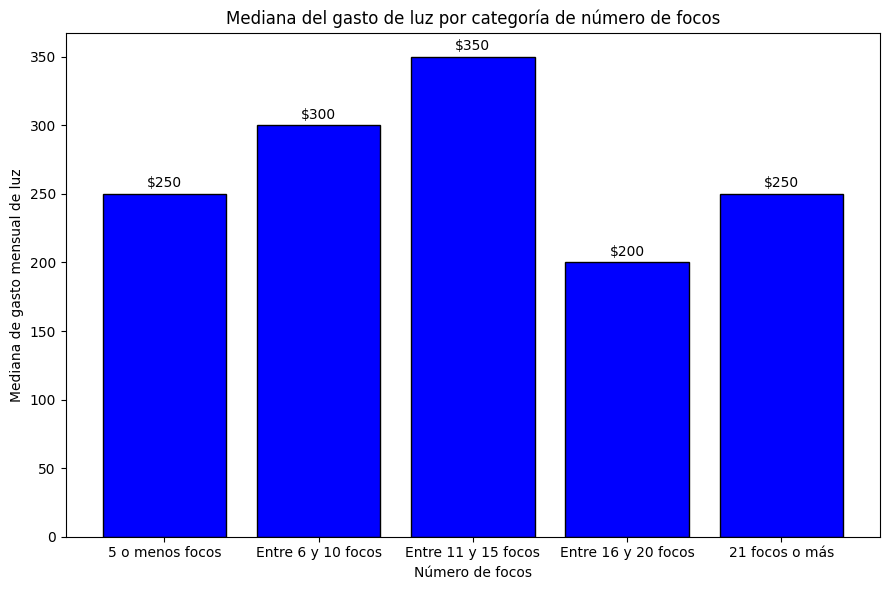

In [5]:
p3=df[["¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?","¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Luz"]].copy()
p3=p3[p3["¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?"] !="No sé"]
p3=p3[p3["¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Luz"] <= 100000]

valor={
    "5 o menos focos": 3,
    "Entre 6 y 10 focos": 8,
    "Entre 11 y 15 focos": 13,
    "Entre 16 y 20 focos": 18,
    "21 focos o más": 23,
}

p3["¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?"] = p3["¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?"].map(valor)
p3


p3v1t="¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?"
p3v2t="¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Luz"
p3v1=p3[p3v1t]
p3v2=p3[p3v2t]

p3cat = df[[p3v1t, p3v2t]].copy()
p3cat = p3cat[p3cat[p3v1t] != "No sé"].copy()
p3cat[p3v2t] = pd.to_numeric(p3cat[p3v2t], errors="coerce")
p3cat = p3cat.dropna(subset=[p3v2t])
p3cat = p3cat[p3cat[p3v2t] <= 100000].copy()


fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    p3[p3v1t],
    p3[p3v2t],
    alpha=0.5, color="steelblue"
)

ax.set_xlabel("Número de focos / Mét. de punto medio")
ax.set_ylabel("Pago mensual de luz")
ax.set_title("Relación entre número de focos y pago de luz")

plt.tight_layout()
guardar_y_mostrar("P03", 1)


supuestos_p3 = evaluar_supuestos_parametricos(p3, p3v1t, p3v2t)
supuestos_p3


pruebas_p3 = pruebas_no_parametricas(p3, p3v1t, p3v2t)
display(pruebas_p3)


kruskal_p3 = kruskal_wallis(p3cat, p3v1t, p3v2t)
display(kruskal_p3)


medianas_p3 = p3cat.groupby(p3v1t)[p3v2t].median()
pares_p3 = mann_whitney_pares(p3cat, p3v1t, p3v2t)
display(medianas_p3)
pares_p3


orden=["5 o menos focos", "Entre 6 y 10 focos", "Entre 11 y 15 focos", "Entre 16 y 20 focos", "21 focos o más"]

medianas=p3cat.groupby("¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?")\
    ["¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Luz"]\
    .median()\
    .reindex(orden)

fig, ax=plt.subplots(figsize=(9, 6))

ax.bar(medianas.index, medianas.values, color="blue", edgecolor="black")

for i, v in enumerate(medianas.values):
    ax.text(i, v + 5, f"${v:.0f}", ha="center")

ax.set_xlabel("Número de focos")
ax.set_ylabel("Mediana de gasto mensual de luz")
ax.set_title("Mediana del gasto de luz por categoría de número de focos")
plt.xticks(rotation=0, ha="center")

plt.tight_layout()
guardar_y_mostrar("P03", 2)


# 4


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P04_grafica_01.png


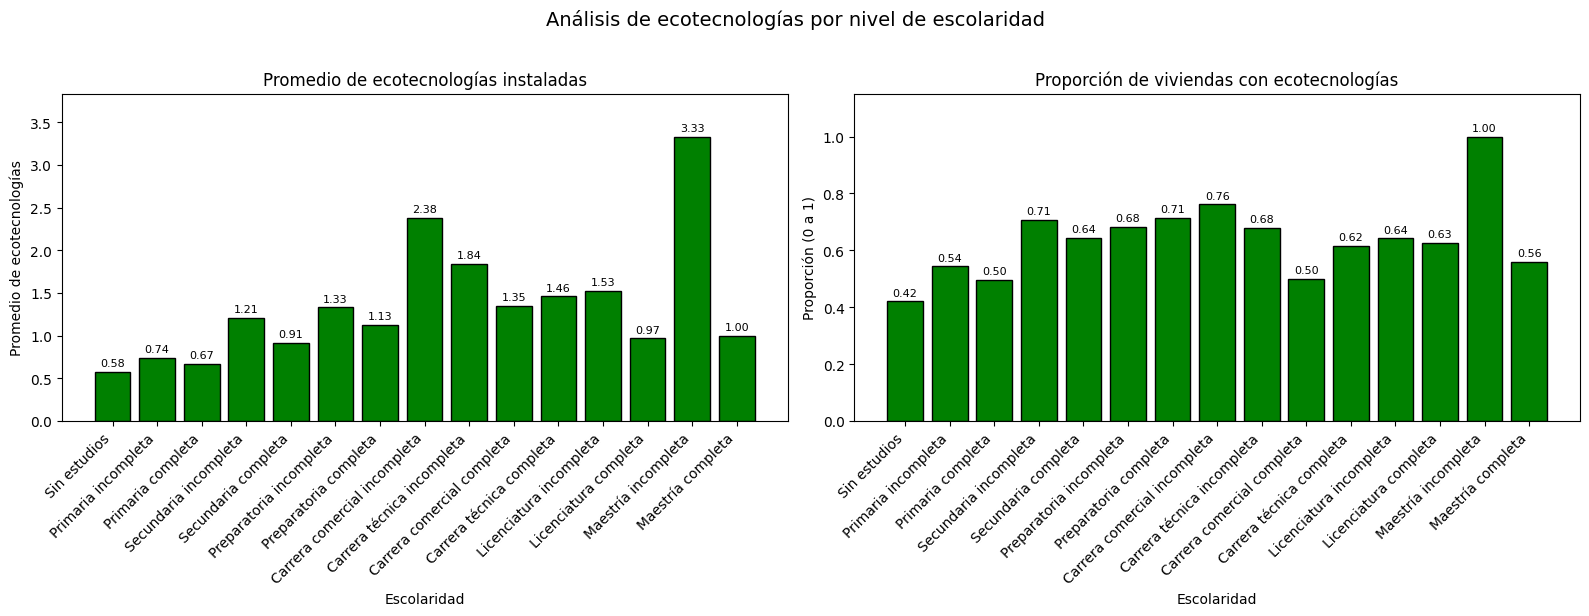

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P04_grafica_02.png


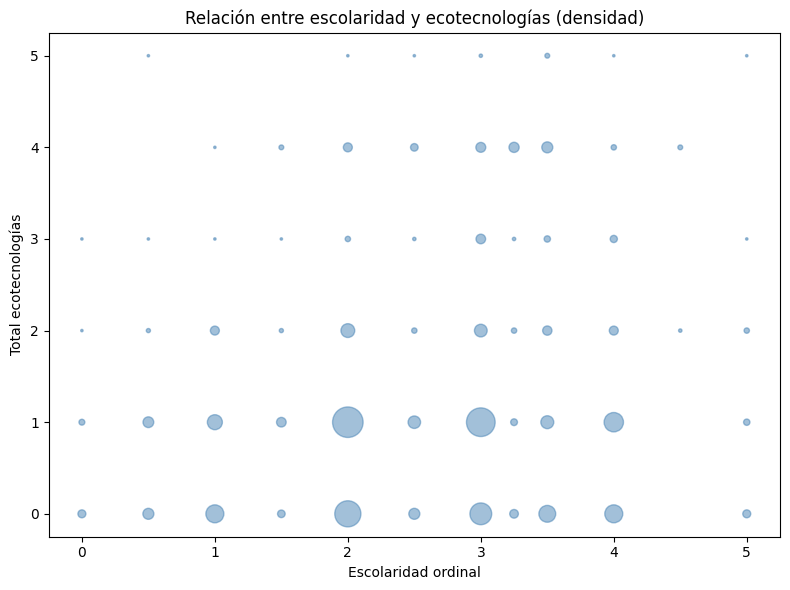

{'spearman': {'prueba': 'Spearman',
  'n': 1247,
  'estadistico': 0.12206779591995848,
  'p_valor': 1.5432943560577992e-05,
  'effect_size': 0.12206779591995848,
  'magnitud': 'Débil',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.15801493237820932,
 'mutual_information': 0.0332106797290157,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1247,
  'estadistico': 60.574903499008016,
  'p_valor': 9.299126687228222e-08,
  'effect_size': 0.048615492374805794,
  'magnitud': 'Pequeño',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí',
  'grupo_min_n': 6}}

In [6]:
p4v1t="Escolaridad"
p4v2t="Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Focos ahorradores"
p4v3t="Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Regaderas ahorradoras"
p4v4t="Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Llaves de agua ahorradoras"
p4v5t="Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Calentador solar de agua"
p4v6t="Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Panel solar / fotovoltaicos"
tec_ahrr=[p4v2t, p4v3t, p4v4t, p4v5t, p4v6t]

p4 = df[[p4v1t] + tec_ahrr].copy()

p4[tec_ahrr] = p4[tec_ahrr].apply(
    lambda col: col.map({"Sí": 1, "No": 0})
)

p4 = p4.dropna(subset=[p4v1t] + tec_ahrr).copy()

p4["total_ecotecnologias"] = p4[tec_ahrr].sum(axis=1)

p4 = pd.DataFrame({
    "Escolaridad": p4[p4v1t],
    "total_ecotecnologias": p4[tec_ahrr].sum(axis=1),
})
p4["instalo_alguna"] = p4["total_ecotecnologias"] > 0

orden={
    "Sin estudios":0,
    "Primaria incompleta":.5,
    "Primaria completa":1,
    "Secundaria incompleta":1.5,
    "Secundaria completa":2,
    "Preparatoria incompleta":2.5,
    "Preparatoria completa":3,
    "Carrera comercial incompleta":3.25,
    "Carrera técnica incompleta":3.25,
    "Carrera comercial completa":3.5,
    "Carrera técnica completa":3.5,
    "Licenciatura incompleta":3.5,
    "Licenciatura completa":4,
    "Maestría incompleta":4.5,
    "Maestría completa":5
}

p4["Esc_ord_enc"]=p4.Escolaridad.map(orden)
p4 = p4.dropna()

p4

# ---

orden_categorias = [
    "Sin estudios", "Primaria incompleta", "Primaria completa",
    "Secundaria incompleta", "Secundaria completa",
    "Preparatoria incompleta", "Preparatoria completa",
    "Carrera comercial incompleta", "Carrera técnica incompleta",
    "Carrera comercial completa", "Carrera técnica completa",
    "Licenciatura incompleta", "Licenciatura completa",
    "Maestría incompleta", "Maestría completa"
]

promedio_por_escolaridad = p4.groupby("Escolaridad")["total_ecotecnologias"].mean().reindex(orden_categorias)
booleano_por_escolaridad = p4.groupby("Escolaridad")["instalo_alguna"].mean().reindex(orden_categorias)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(promedio_por_escolaridad.index, promedio_por_escolaridad.values, color="green", edgecolor="black")

for i, v in enumerate(promedio_por_escolaridad.values):
    if pd.notna(v):
        ax1.text(i, v + (promedio_por_escolaridad.max() * 0.02), f"{v:.2f}", ha="center", fontsize=8)

ax1.set_title("Promedio de ecotecnologías instaladas")
ax1.set_xlabel("Escolaridad")
ax1.set_ylabel("Promedio de ecotecnologías")
ax1.set_ylim(0, promedio_por_escolaridad.max() * 1.15)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2.bar(booleano_por_escolaridad.index, booleano_por_escolaridad.values, color="green", edgecolor="black")

for i, v in enumerate(booleano_por_escolaridad.values):
    if pd.notna(v):
        ax2.text(i, v + (booleano_por_escolaridad.max() * 0.02), f"{v:.2f}", ha="center", fontsize=8)

ax2.set_title("Proporción de viviendas con ecotecnologías")
ax2.set_xlabel("Escolaridad")
ax2.set_ylabel("Proporción (0 a 1)")
ax2.set_ylim(0, max(booleano_por_escolaridad.max() * 1.15, 1.05))  # Espacio para los números
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

# Título global y ajuste de layout
plt.suptitle("Análisis de ecotecnologías por nivel de escolaridad", fontsize=14, y=1.02)
plt.tight_layout()
guardar_y_mostrar("P04", 1)

conteo_combinaciones = p4.groupby(["Esc_ord_enc", "total_ecotecnologias"]).size().reset_index(name="conteo")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    conteo_combinaciones["Esc_ord_enc"],
    conteo_combinaciones["total_ecotecnologias"],
    s=conteo_combinaciones["conteo"] * 3,
    alpha=0.5, color="steelblue"
)
ax.set_xlabel("Escolaridad ordinal")
ax.set_ylabel("Total ecotecnologías")
ax.set_title("Relación entre escolaridad y ecotecnologías (densidad)")
plt.tight_layout()
guardar_y_mostrar("P04", 2)


supuestos_p4 = evaluar_supuestos_parametricos(p4, "Esc_ord_enc", "total_ecotecnologias")
supuestos_p4


pruebas_p4 = pruebas_no_parametricas(
    p4, "Esc_ord_enc", "total_ecotecnologias", col_categorica="Escolaridad"
)
pruebas_p4


# 5


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P05_grafica_01.png


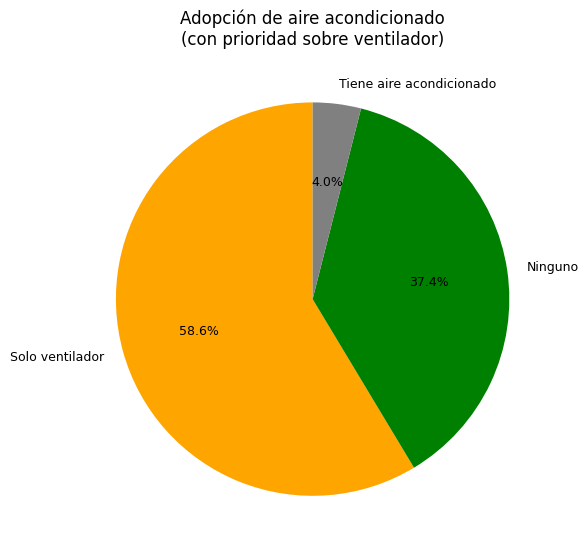

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P05_grafica_02.png


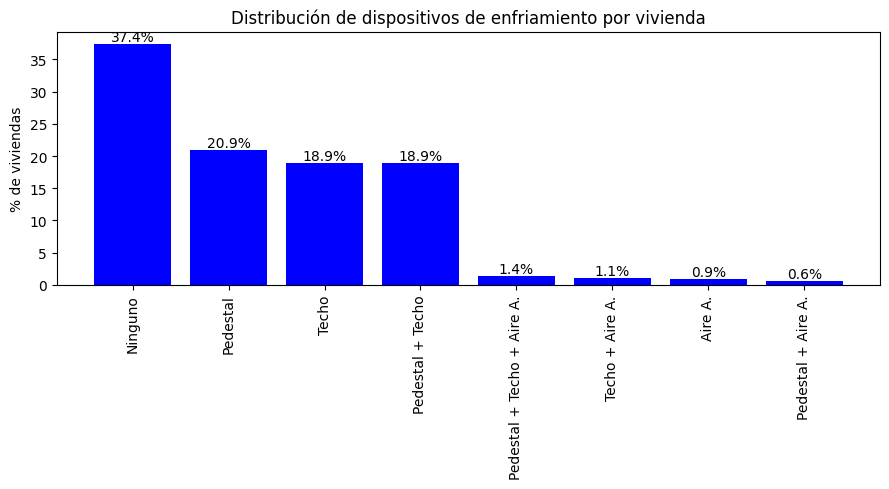

In [7]:
p5v1t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Sala comedor Ventilador de techo"
p5v2t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Sala comedor Ventilador de pedestal"
p5v3t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Sala comedor Aire acondicionado"
p5v4t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Cocina Ventilador de techo"
p5v5t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Cocina Ventilador de pedestal"
p5v6t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Cocina Aire acondicionado"
p5v7t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Dormitorios Ventilador de techo"
p5v8t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Dormitorios Ventilador de pedestal"
p5v9t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Dormitorios Aire acondicionado"
p5v10t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Baños Ventilador de techo"
p5v11t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Baños Ventilador de pedestal"
p5v12t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Baños Aire acondicionado"
p5v13t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Patio Ventilador de techo"
p5v14t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Patio Ventilador de pedestal"
p5v15t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Patio Aire acondicionado"

columnas_p5 = [
    p5v1t, p5v2t, p5v3t, p5v4t, p5v5t,
    p5v6t, p5v7t, p5v8t, p5v9t, p5v10t,
    p5v11t, p5v12t, p5v13t, p5v14t, p5v15t
]

p5 = df[columnas_p5].copy()
p5[columnas_p5] = p5[columnas_p5].apply(
    lambda col: pd.to_numeric(
        col.map(lambda v: 0 if v == "Ninguno" else v),
        errors="coerce",
    )
)

p5


cols_ventilador = [p5v1t, p5v2t, p5v4t, p5v5t, p5v7t, p5v8t, p5v10t, p5v11t, p5v13t, p5v14t]
cols_aire = [p5v3t, p5v6t, p5v9t, p5v12t, p5v15t]

tiene_aire = p5[cols_aire].sum(axis=1) > 0
tiene_ventilador = p5[cols_ventilador].sum(axis=1) > 0

def clasificar_prioridad(row):
    if row["aire"]:
        return "Tiene aire acondicionado"
    elif row["ventilador"]:
        return "Solo ventilador"
    else:
        return "Ninguno"

p5r1 = pd.DataFrame({
    "aire": tiene_aire,
    "ventilador": tiene_ventilador,
}).apply(clasificar_prioridad, axis=1)

p5r1


conteo = p5r1.value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    conteo.values,
    labels=conteo.index,
    colors=["orange", "green", "gray"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 9}
)
ax.set_title("Adopción de aire acondicionado\n(con prioridad sobre ventilador)")
plt.tight_layout()
guardar_y_mostrar("P05", 1)


cols_solovtecho = [p5v1t, p5v4t, p5v7t, p5v10t, p5v13t]
cols_solovpedestal = [p5v2t, p5v5t, p5v8t, p5v11t, p5v14t]
cols_aire = [p5v3t, p5v6t, p5v9t, p5v12t, p5v15t]

tiene_pedestal = p5[cols_solovpedestal].sum(axis=1) > 0
tiene_techo = p5[cols_solovtecho].sum(axis=1) > 0
tiene_aire = p5[cols_aire].sum(axis=1) > 0

def clasificar_combinacion(row):
    tipos = []
    if row["pedestal"]:
        tipos.append("Pedestal")
    if row["techo"]:
        tipos.append("Techo")
    if row["aire"]:
        tipos.append("Aire A.")
    if not tipos:
        return "Ninguno"
    return " + ".join(tipos)

p5r2 = pd.DataFrame({
    "pedestal": tiene_pedestal,
    "techo": tiene_techo,
    "aire": tiene_aire,
}).apply(clasificar_combinacion, axis=1)

p5r2


conteo_pct = p5r2.value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(
    conteo_pct.index.astype(str),
    conteo_pct.values,
    color="blue"
)

ax.bar_label(
    barras,
    labels=[f"{v:.1f}%" for v in conteo_pct.values]
)

ax.set_title("Distribución de dispositivos de enfriamiento por vivienda")
ax.set_ylabel("% de viviendas")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
guardar_y_mostrar("P05", 2)

# 6


(1167, 3)
Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P06_grafica_01.png


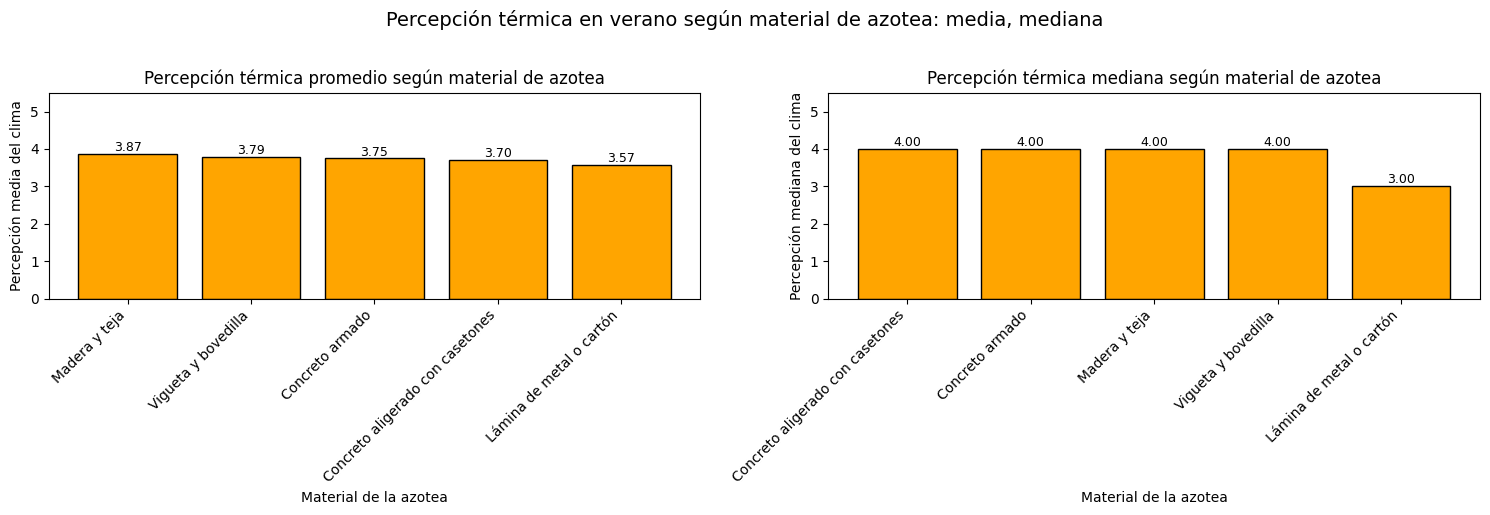

{'prueba': 'Kruskal-Wallis',
 'n': 1167,
 'estadistico': 2.3738400991825546,
 'p_valor': 0.6673598550857568,
 'effect_size': 0.002035883446983323,
 'magnitud': 'Trivial',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'No',
 'grupo_min_n': 7}

In [8]:
p6v1t = "De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno?  | En verano"
p6v2t = "De las siguientes opciones, ¿Cuál es el tipo de material de la azotea de esta vivienda? "

valor_clima = {
    "Muy fría": 1,
    "Fría": 2,
    "Neutra": 3,
    "Calurosa": 4,
    "Muy calurosa": 5,
}

p6 = df[[p6v1t, p6v2t]].copy()
p6["clm_per_ord_enc"] = p6[p6v1t].map(valor_clima)
p6[p6v2t] = p6[p6v2t].str.replace(r'^\d+\s*', '', regex=True)
p6.loc[p6[p6v2t].eq("No sé"), p6v2t] = np.nan

p6 = p6.dropna(subset=["clm_per_ord_enc", p6v2t])
print(p6.shape)
p6


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

media_clima_azotea = (
    p6.groupby(p6v2t)["clm_per_ord_enc"]
    .mean()
    .sort_values(ascending=False)
)

ax1.bar(media_clima_azotea.index, media_clima_azotea.values,
        color="orange", edgecolor="black")

for i, v in enumerate(media_clima_azotea.values):
    if pd.notna(v):
        ax1.text(i, v + (media_clima_azotea.max() * 0.02), f"{v:.2f}",
                  ha="center", fontsize=9)

ax1.set_title("Percepción térmica promedio según material de azotea")
ax1.set_xlabel("Material de la azotea")
ax1.set_ylabel("Percepción media del clima")
ax1.set_ylim(0, max(media_clima_azotea.max() * 1.15, 5.5))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

mediana_clima_azotea = (
    p6.groupby(p6v2t)["clm_per_ord_enc"]
    .median()
    .sort_values(ascending=False)
)

ax2.bar(mediana_clima_azotea.index, mediana_clima_azotea.values,
        color="orange", edgecolor="black")

for i, v in enumerate(mediana_clima_azotea.values):
    if pd.notna(v):
        ax2.text(i, v + (mediana_clima_azotea.max() * 0.02), f"{v:.2f}",
                  ha="center", fontsize=9)

ax2.set_title("Percepción térmica mediana según material de azotea")
ax2.set_xlabel("Material de la azotea")
ax2.set_ylabel("Percepción mediana del clima")
ax2.set_ylim(0, max(mediana_clima_azotea.max() * 1.15, 5.5))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Percepción térmica en verano según material de azotea: media, mediana", fontsize=14, y=1.02)
plt.tight_layout()
guardar_y_mostrar("P06", 1)


supuestos_grupos_p6 = normalidad_y_levene_por_grupos(p6, p6v2t, "clm_per_ord_enc")
supuestos_grupos_p6["levene"]


kruskal_p6 = kruskal_wallis(p6, p6v2t, "clm_per_ord_enc")
kruskal_p6


# 7


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P07_grafica_01.png


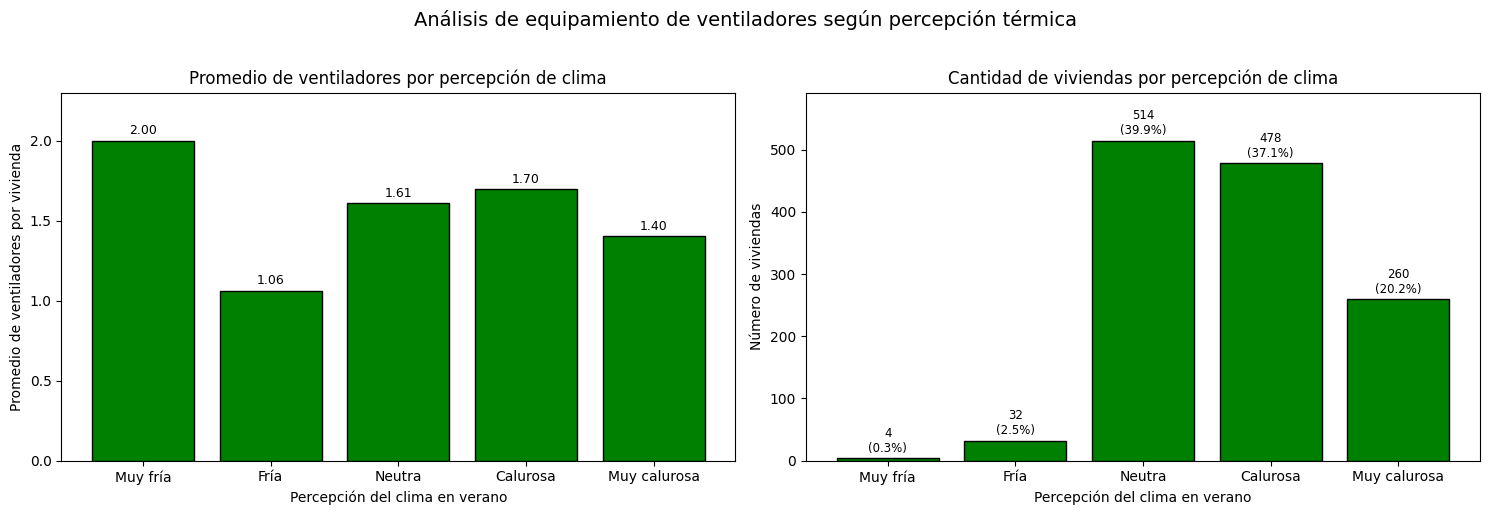

{'spearman': {'prueba': 'Spearman',
  'n': 1288,
  'estadistico': -0.019055732038604545,
  'p_valor': 0.49442752503593623,
  'effect_size': -0.019055732038604545,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'No'},
 'distance_correlation': 0.056258099384654606,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1288,
  'estadistico': 11.28055096463875,
  'p_valor': 0.023585526679104588,
  'effect_size': 0.008764996864521172,
  'magnitud': 'Trivial',
  'estado': 'Válida con advertencia',
  'advertencia': 'grupo menor n=4',
  'significativo': 'Sí',
  'grupo_min_n': 4}}

In [9]:
p7v1t = "De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno?  | En verano"

p7v2t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Sala comedor Ventilador de pedestal"
p7v3t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Cocina Ventilador de techo"
p7v4t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Cocina Ventilador de pedestal"
p7v5t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Dormitorios Ventilador de techo"
p7v6t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Dormitorios Ventilador de pedestal"
p7v7t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Baños Ventilador de techo"
p7v8t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Baños Ventilador de pedestal"
p7v9t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Patio Ventilador de techo"
p7v10t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Patio Ventilador de pedestal"
p7v11t = "Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Sala comedor Ventilador de techo"

col_ventiladores = [p7v2t, p7v3t, p7v4t, p7v5t, p7v6t, p7v7t, p7v8t, p7v9t, p7v10t, p7v11t]

p7 = df[col_ventiladores + [p7v1t]].copy()

valor_clima = {
    "Muy fría": 1,
    "Fría": 2,
    "Neutra": 3,
    "Calurosa": 4,
    "Muy calurosa": 5,
}

p7["clm_per_ord_enc"]=p7[p7v1t].map(valor_clima)
p7[col_ventiladores] = p7[col_ventiladores].apply(
    lambda col: pd.to_numeric(
        col.map(lambda v: 0 if v == "Ninguno" else v),
        errors="coerce",
    )
)
p7["total_ventiladores"]=p7[col_ventiladores].sum(axis=1)
p7=p7.drop(columns=col_ventiladores)
p7

     
orden_clima = ["Muy fría", "Fría", "Neutra", "Calurosa", "Muy calurosa"]

promedio_ventiladores = (p7.groupby(p7v1t)["total_ventiladores"].mean().reindex(orden_clima))
frecuencia_clima = (p7.groupby(p7v1t)["total_ventiladores"].count().reindex(orden_clima))
porcentaje_clima = (frecuencia_clima / frecuencia_clima.sum()) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(promedio_ventiladores.index, promedio_ventiladores.values, color="green", edgecolor="black")

for i, v in enumerate(promedio_ventiladores.values):
    if pd.notna(v):
        ax1.text(i, v + (promedio_ventiladores.max() * 0.02), f"{v:.2f}", ha="center", fontsize=9)

ax1.set_title("Promedio de ventiladores por percepción de clima")
ax1.set_xlabel("Percepción del clima en verano")
ax1.set_ylabel("Promedio de ventiladores por vivienda")
ax1.set_ylim(0, promedio_ventiladores.max() * 1.15)
plt.setp(ax1.get_xticklabels(), rotation=0)

ax2.bar(frecuencia_clima.index, frecuencia_clima.values, color="green", edgecolor="black")

for i, v in enumerate(frecuencia_clima.values):
    if pd.notna(v):
        pct = porcentaje_clima.values[i]
        texto_etiqueta = f"{int(v)}\n({pct:.1f}%)"
        ax2.text(i, v + (frecuencia_clima.max() * 0.02), texto_etiqueta, ha="center", fontsize=8.5)

ax2.set_title("Cantidad de viviendas por percepción de clima")
ax2.set_xlabel("Percepción del clima en verano")
ax2.set_ylabel("Número de viviendas")
ax2.set_ylim(0, frecuencia_clima.max() * 1.15)
plt.setp(ax2.get_xticklabels(), rotation=0)

plt.suptitle("Análisis de equipamiento de ventiladores según percepción térmica", fontsize=14, y=1.02)
plt.tight_layout()
guardar_y_mostrar("P07", 1)


supuestos_p7 = evaluar_supuestos_parametricos(p7, "total_ventiladores", "clm_per_ord_enc")
supuestos_p7


if not supuestos_p7["todos_cumplen"]:
    pruebas_p7 = pruebas_no_parametricas(
        p7, "total_ventiladores", "clm_per_ord_enc"
    )
    pruebas_p7["kruskal_wallis"] = kruskal_wallis(
        p7, p7v1t, "total_ventiladores"
    )
    display(pruebas_p7)


# 8


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P08_grafica_01.png


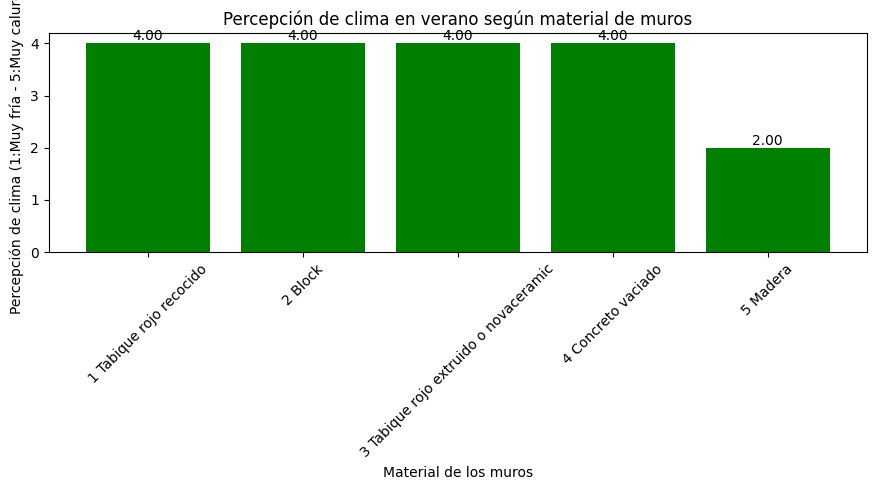

,grupo,n,W,p_valor,normal,advertencia
0,1 Tabique rojo recocido,653,0.840188,4.398107e-25,False,None
1,2 Block,372,0.831508,1.856024e-19,False,None
2,3 Tabique rojo extruido o novaceramic,20,0.852890,5.961394e-03,False,None
3,4 Concreto vaciado,185,0.823622,1.076323e-13,False,None
4,5 Madera,1,NaN,NaN,None,Menos de 3 observaciones


{'estadistico': 0.8702710415926586,
 'p_valor': 0.48108091233443717,
 'homogeneidad': True}

{'prueba': 'Kruskal-Wallis',
 'n': 1231,
 'estadistico': 10.29777476476208,
 'p_valor': 0.03569958444846177,
 'effect_size': 0.008372174605497626,
 'magnitud': 'Trivial',
 'estado': 'Válida con advertencia',
 'advertencia': 'grupo menor n=1',
 'significativo': 'Sí',
 'grupo_min_n': 1}

De las siguientes opciones, ¿Cuál es el tipo de material de los muros de esta vivienda?
1 Tabique rojo recocido                  653
2 Block                                  372
4 Concreto vaciado                       185
3 Tabique rojo extruido o novaceramic     20
5 Madera                                   1
Name: count, dtype: int64

In [10]:
p8v1t = "De las siguientes opciones, ¿Cuál es el tipo de material de los muros de esta vivienda?"
p8v2t = "De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno?  | En verano"

valor_clima = {
    "Muy fría": 1,
    "Fría": 2,
    "Neutra": 3,
    "Calurosa": 4,
    "Muy calurosa": 5,
}

p8 = df[[p8v1t, p8v2t]].copy()
p8.loc[p8[p8v1t].astype(str).str.contains("No sé", case=False, na=False), p8v1t] = np.nan
p8["clm_ord_enc"] = p8[p8v2t].map(valor_clima)

ax = grafica_resumen_grupos(
    p8, p8v1t, "clm_ord_enc",
    estadistico="mediana",
    titulo="Percepción de clima en verano según material de muros",
    xlabel="Material de los muros",
    ylabel="Percepción de clima (1:Muy fría - 5:Muy calurosa)",
    rotacion=45,
)

for barra in ax.patches:
    barra.set_facecolor("green")

guardar_y_mostrar("P08", 1)

supuestos_grupos_p8 = normalidad_y_levene_por_grupos(p8, p8v1t, "clm_ord_enc")
display(supuestos_grupos_p8["normalidad"])
display(supuestos_grupos_p8["levene"])

kruskal_p8 = kruskal_wallis(p8, p8v1t, "clm_ord_enc")
display(kruskal_p8)


p8[p8v1t].value_counts()


In [11]:
p8_sens = p8[
    ~p8[p8v1t].astype(str).str.contains("Madera", case=False, na=False)
].copy()

kruskal_wallis(
    p8_sens,
    p8v1t,
    "clm_ord_enc"
)

{'prueba': 'Kruskal-Wallis',
 'n': 1230,
 'estadistico': 7.081239598107778,
 'p_valor': 0.06935297699980998,
 'effect_size': 0.005761789746222765,
 'magnitud': 'Trivial',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'No',
 'grupo_min_n': 20}

# 9


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P09_grafica_01.png


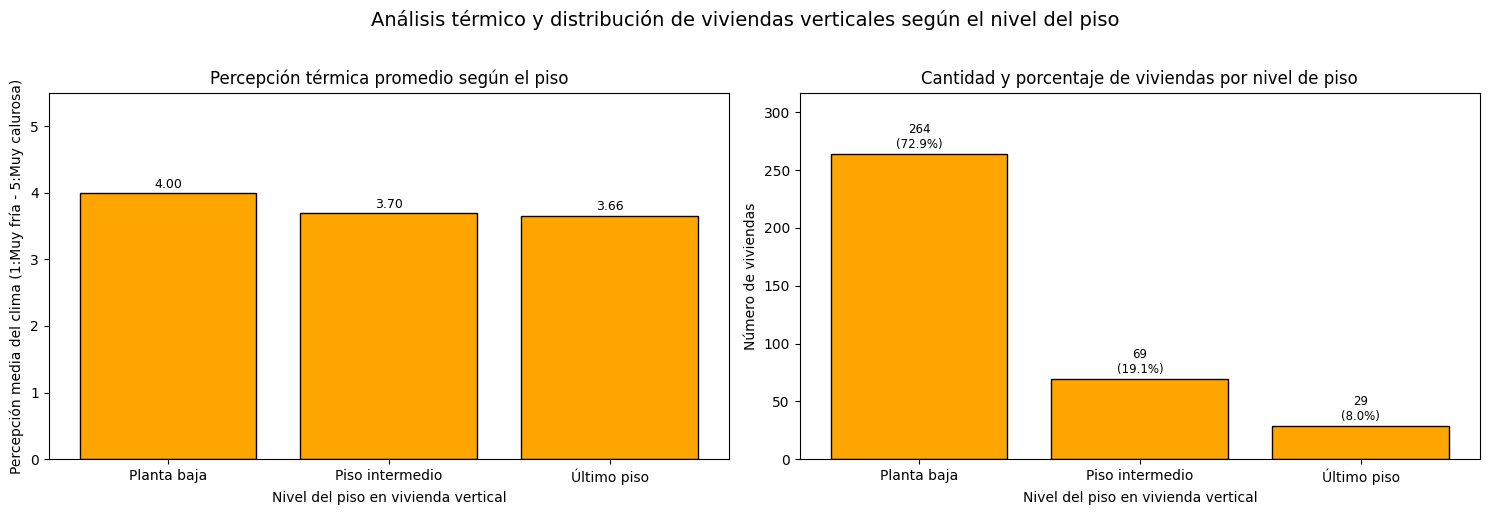

{'spearman': {'prueba': 'Spearman',
  'n': 362,
  'estadistico': -0.15980123314848418,
  'p_valor': 0.002291993723470501,
  'effect_size': -0.15980123314848418,
  'magnitud': 'Débil',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.15182200854449765,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 362,
  'estadistico': 9.300203061550866,
  'p_valor': 0.00956063118296633,
  'effect_size': 0.025762335350556415,
  'magnitud': 'Pequeño',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí',
  'grupo_min_n': 29}}

In [12]:
p9v1t="¿Si es vivienda vertical, en qué piso se encuentra? "
p9v2t="De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno?  | En verano"

p9=df[[p9v1t, p9v2t]].copy()
p9=p9[p9[p9v1t] != "No aplica/es vivienda horizontal"]

p9=p9.dropna(subset=[p9v1t])

valor_piso = { 
    "Planta baja":1,
    "Piso intermedio":2,
    "Último piso":3,
}

valor_clima={
    "Muy fría":1,
    "Fría":2,
    "Neutra":3,
    "Calurosa":4,
    "Muy calurosa":5,
}


p9["piso_ord_enc"]=p9[p9v1t].map(valor_piso)
p9["clm_ord_enc"]=p9[p9v2t].map(valor_clima)

p9

# ---

orden_pisos = ["Planta baja", "Piso intermedio", "Último piso"]

promedio_clima_piso = (
    p9.groupby(p9v1t)["clm_ord_enc"]
    .mean()
    .reindex(orden_pisos)
)

frecuencia_pisos = (
    p9.groupby(p9v1t)["clm_ord_enc"]
    .count()
    .reindex(orden_pisos)
)

total_viviendas_p9 = frecuencia_pisos.sum()
porcentaje_pisos = (frecuencia_pisos / total_viviendas_p9) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(promedio_clima_piso.index, promedio_clima_piso.values, color="orange", edgecolor="black")

for i, v in enumerate(promedio_clima_piso.values):
    if pd.notna(v):
        ax1.text(i, v + (promedio_clima_piso.max() * 0.02), f"{v:.2f}", ha="center", fontsize=9)

ax1.set_title("Percepción térmica promedio según el piso")
ax1.set_xlabel("Nivel del piso en vivienda vertical")
ax1.set_ylabel("Percepción media del clima (1:Muy fría - 5:Muy calurosa)")
ax1.set_ylim(0, max(promedio_clima_piso.max() * 1.15, 5.5))
plt.setp(ax1.get_xticklabels(), rotation=0)

ax2.bar(frecuencia_pisos.index, frecuencia_pisos.values, color="orange", edgecolor="black")

for i, v in enumerate(frecuencia_pisos.values):
    if pd.notna(v):
        pct = porcentaje_pisos.values[i]
        texto_etiqueta = f"{int(v)}\n({pct:.1f}%)"
        ax2.text(i, v + (frecuencia_pisos.max() * 0.02), texto_etiqueta, ha="center", fontsize=8.5)

ax2.set_title("Cantidad y porcentaje de viviendas por nivel de piso")
ax2.set_xlabel("Nivel del piso en vivienda vertical")
ax2.set_ylabel("Número de viviendas")
ax2.set_ylim(0, frecuencia_pisos.max() * 1.20)
plt.setp(ax2.get_xticklabels(), rotation=0)

plt.suptitle("Análisis térmico y distribución de viviendas verticales según el nivel del piso", fontsize=14, y=1.02)
plt.tight_layout()
guardar_y_mostrar("P09", 1)


supuestos_p9 = evaluar_supuestos_parametricos(p9, "piso_ord_enc", "clm_ord_enc")
supuestos_p9


if not supuestos_p9["todos_cumplen"]:
    pruebas_p9 = pruebas_no_parametricas(
        p9, "piso_ord_enc", "clm_ord_enc", col_categorica=p9v1t
    )
    display(pruebas_p9)


# 10


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P10_grafica_01.png


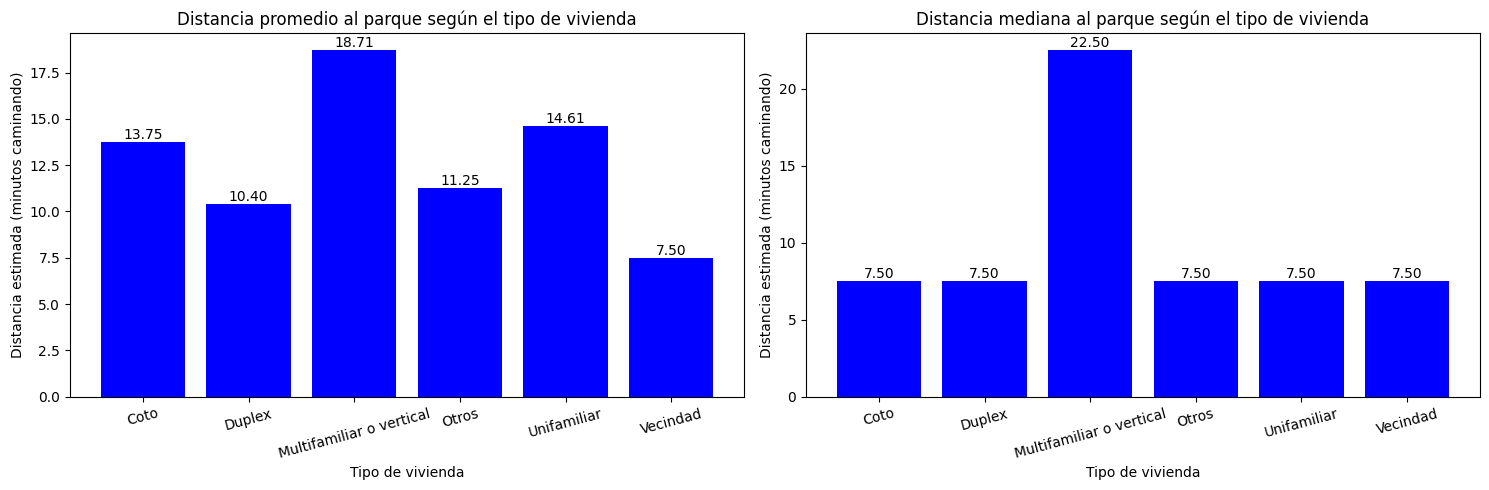

,grupo,n,W,p_valor,normal,advertencia
0,Coto,12,0.639593,2.342223e-04,False,None
1,Duplex,31,0.484775,2.555810e-09,False,None
2,Multifamiliar o vertical,259,0.770446,9.480280e-19,False,None
3,Otros,8,0.565941,6.322980e-05,False,None
4,Unifamiliar,662,0.701014,1.220017e-32,False,None
5,Vecindad,3,NaN,NaN,None,Grupo constante


{'prueba': 'Kruskal-Wallis',
 'n': 975,
 'estadistico': 55.656582152091204,
 'p_valor': 9.563407705043812e-11,
 'effect_size': 0.05714228147031951,
 'magnitud': 'Pequeño',
 'estado': 'Válida con advertencia',
 'advertencia': 'grupo menor n=3',
 'significativo': 'Sí',
 'grupo_min_n': 3}

In [13]:
p10v1t = "¿A qué distancia de su vivienda se encuentra el parque o espacio público que frecuenta más a menudo? "
p10v2t = "La vivienda es… "

punto_medio_distancia = {
    "A menos de 15 minutos caminando": 7.5,
    "Entre 15 y 30 minutos caminando": 22.5,
    "No hay parques o espacios públicos cercanos": np.nan,
    "Más de 30 minutos en caminando": 33.75
}

p10 = df[[p10v2t, p10v1t]].copy()
p10[p10v1t] = p10[p10v1t].map(punto_medio_distancia)

p10 = p10.dropna(subset=[p10v1t, p10v2t])
p10


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

grafica_resumen_grupos(
    p10, p10v2t, p10v1t, estadistico="media",
    titulo="Distancia promedio al parque según el tipo de vivienda",
    xlabel="Tipo de vivienda",
    ylabel="Distancia estimada (minutos caminando)",
    rotacion=15,
    ax=ax1
)

grafica_resumen_grupos(
    p10, p10v2t, p10v1t, estadistico="mediana",
    titulo="Distancia mediana al parque según el tipo de vivienda",
    xlabel="Tipo de vivienda",
    ylabel="Distancia estimada (minutos caminando)",
    rotacion=15,
    ax=ax2
)

# Cambiar únicamente estas barras a azul
for barra in ax1.patches:
    barra.set_facecolor("blue")

for barra in ax2.patches:
    barra.set_facecolor("blue")

plt.tight_layout()
guardar_y_mostrar("P10", 1)


supuestos_grupos_p10 = normalidad_y_levene_por_grupos(p10, p10v2t, p10v1t)
display(supuestos_grupos_p10["normalidad"])
supuestos_grupos_p10["levene"]


kruskal_p10 = kruskal_wallis(p10, p10v2t, p10v1t)
kruskal_p10


# 11


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P11_grafica_01.png


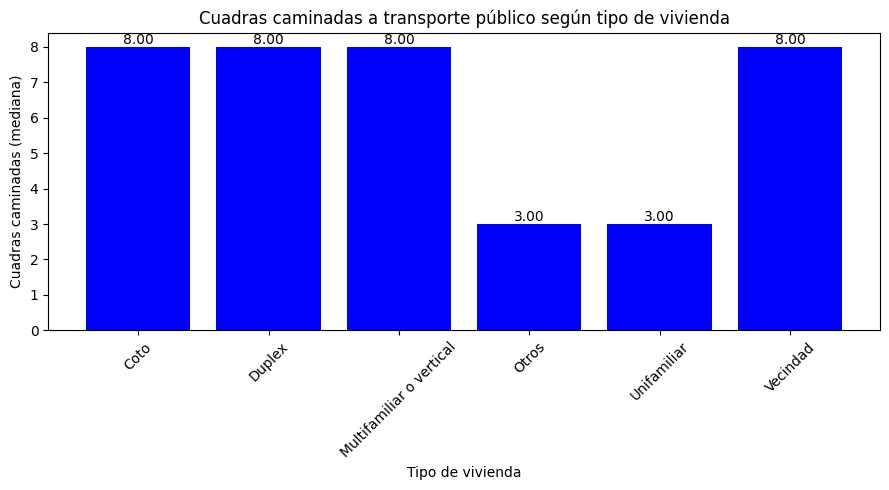

,grupo,n,W,p_valor,normal,advertencia
0,Coto,1,NaN,NaN,None,Menos de 3 observaciones
1,Duplex,21,0.738728,8.715810e-05,False,None
2,Multifamiliar o vertical,118,0.733337,2.385493e-13,False,None
3,Otros,5,0.684029,6.470001e-03,False,None
4,Unifamiliar,313,0.723181,1.861967e-22,False,None
5,Vecindad,3,0.750000,7.771561e-16,False,None


{'estadistico': 0.278627039225068,
 'p_valor': 0.9247955649639226,
 'homogeneidad': True}

{'prueba': 'Kruskal-Wallis',
 'n': 461,
 'estadistico': 3.508893163183816,
 'p_valor': 0.6220424082144103,
 'effect_size': 0.007628028615616991,
 'magnitud': 'Trivial',
 'estado': 'Válida con advertencia',
 'advertencia': 'grupo menor n=1',
 'significativo': 'No',
 'grupo_min_n': 1}

In [14]:
p11v1t = 'La vivienda es… '
p11v2t = 'Si el o la jefe(a) de familia utiliza el transporte público para ir a trabajar, ¿cuántas cuadras tiene que caminar para llegar a la parada o estación?'

valor_cuadras = {'Menos de 5 cuadras': 3, 'De 6 a 10 cuadras': 8, 'Más de 10 cuadras': 13}

p11 = df[[p11v1t, p11v2t]].copy()
p11[p11v2t] = p11[p11v2t].map(valor_cuadras)

ax = grafica_resumen_grupos(
    p11, p11v1t, p11v2t,
    estadistico="mediana",
    titulo="Cuadras caminadas a transporte público según tipo de vivienda",
    xlabel="Tipo de vivienda",
    ylabel="Cuadras caminadas (mediana)",
    rotacion=45
)

for barra in ax.patches:
    barra.set_facecolor("blue")

guardar_y_mostrar("P11", 1)

supuestos_grupos_p11 = normalidad_y_levene_por_grupos(p11, p11v1t, p11v2t)
display(supuestos_grupos_p11["normalidad"])
display(supuestos_grupos_p11["levene"])

kruskal_p11 = kruskal_wallis(p11, p11v1t, p11v2t)
kruskal_p11


In [15]:
p11_sens = p11[
    ~p11[p11v1t].isin(["Coto", "Vecindad"])
].copy()

kruskal_wallis(
    p11_sens,
    p11v1t,
    p11v2t
)

{'prueba': 'Kruskal-Wallis',
 'n': 457,
 'estadistico': 2.5057194327986085,
 'p_valor': 0.47425834047195925,
 'effect_size': 0.0054949987561372995,
 'magnitud': 'Trivial',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'No',
 'grupo_min_n': 5}

# 12


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P12_grafica_01.png


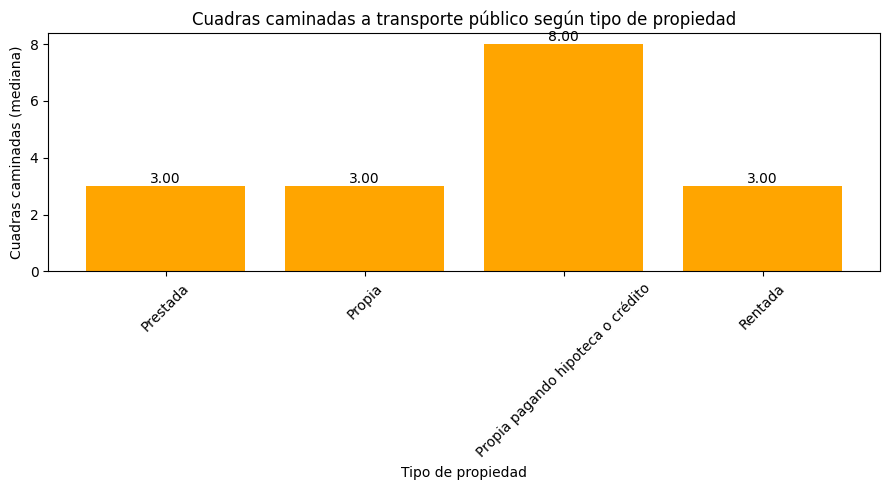

,grupo,n,W,p_valor,normal,advertencia
0,Prestada,30,0.725090,3.694851e-06,False,None
1,Propia,308,0.723210,2.786178e-22,False,None
2,Propia pagando hipoteca o crédito,28,0.778829,4.621460e-05,False,None
3,Rentada,91,0.740677,2.220800e-11,False,None


{'estadistico': 0.14517414343661544,
 'p_valor': 0.9327531331328398,
 'homogeneidad': True}

{'prueba': 'Kruskal-Wallis',
 'n': 457,
 'estadistico': 2.3395922620887104,
 'p_valor': 0.5049785406539222,
 'effect_size': 0.005130684785282259,
 'magnitud': 'Trivial',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'No',
 'grupo_min_n': 28}

In [16]:
p115v1t = 'La vivienda es … '
p115v2t = 'Si el o la jefe(a) de familia utiliza el transporte público para ir a trabajar, ¿cuántas cuadras tiene que caminar para llegar a la parada o estación?'

valor_cuadras = {'Menos de 5 cuadras': 3, 'De 6 a 10 cuadras': 8, 'Más de 10 cuadras': 13}

p115 = df[[p115v1t, p115v2t]].copy()
p115.loc[p115[p115v1t].eq("No sé"), p115v1t] = np.nan
p115[p115v2t] = p115[p115v2t].map(valor_cuadras)

ax = grafica_resumen_grupos(
    p115, p115v1t, p115v2t,
    estadistico="mediana",
    titulo="Cuadras caminadas a transporte público según tipo de propiedad",
    xlabel="Tipo de propiedad",
    ylabel="Cuadras caminadas (mediana)",
    rotacion=45
)

for barra in ax.patches:
    barra.set_facecolor("orange")

guardar_y_mostrar("P12", 1)

supuestos_grupos_p115 = normalidad_y_levene_por_grupos(p115, p115v1t, p115v2t)
display(supuestos_grupos_p115["normalidad"])
display(supuestos_grupos_p115["levene"])

kruskal_p115 = kruskal_wallis(p115, p115v1t, p115v2t)
kruskal_p115


# 13


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P13_grafica_01.png


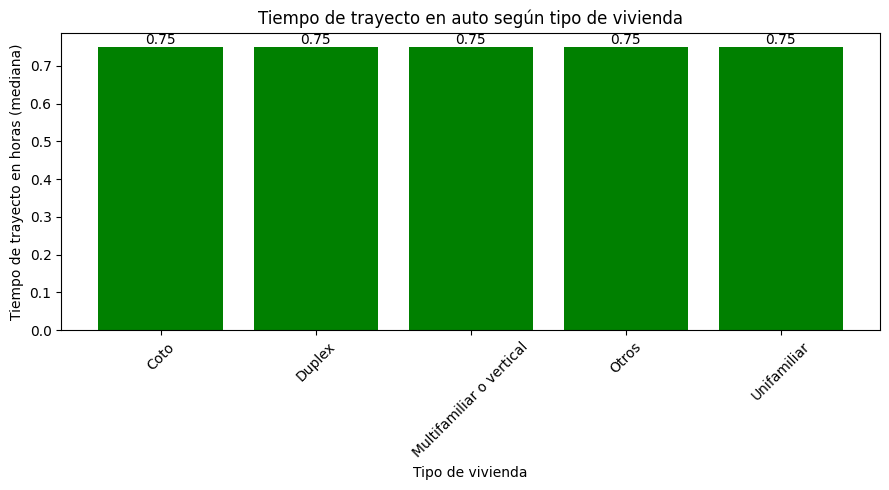

,grupo,n,W,p_valor,normal,advertencia
0,Coto,12,0.780112,5.615595e-03,False,None
1,Duplex,10,0.819705,2.513442e-02,False,None
2,Multifamiliar o vertical,186,0.812974,3.548355e-14,False,None
3,Otros,2,NaN,NaN,None,Menos de 3 observaciones
4,Unifamiliar,490,0.773190,1.759191e-25,False,None


{'estadistico': 12.844690481451371,
 'p_valor': 4.2947460534242926e-10,
 'homogeneidad': False}

{'prueba': 'Kruskal-Wallis',
 'n': 700,
 'estadistico': 5.576911766915892,
 'p_valor': 0.23305113965680818,
 'effect_size': 0.007978414544944051,
 'magnitud': 'Trivial',
 'estado': 'Válida con advertencia',
 'advertencia': 'grupo menor n=2',
 'significativo': 'No',
 'grupo_min_n': 2}

In [17]:
p12v1t = 'La vivienda es… '
p12v2t = 'Si el o la jefe(a) de familia utiliza el automóvil particular para ir a trabajar, ¿Cuánto tiempo le toma en promedio ir y regresar?'

valor_trayecto = {'De 30 minutos a 1 hora': 0.75, 'Menos de 30 minutos': 0.25, 'De 1 hora  a 1 hora, 30 minutos': 1.25, 'Más de 3 horas': 3.25, 'Entre 1 hora, 31 minutos a 2 horas': 1.75, 'De 2 a 3 horas': 2.5}

p12 = df[[p12v1t, p12v2t]].copy()
p12[p12v2t] = p12[p12v2t].map(valor_trayecto)

ax = grafica_resumen_grupos(
    p12, p12v1t, p12v2t,
    estadistico="mediana",
    titulo="Tiempo de trayecto en auto según tipo de vivienda",
    xlabel="Tipo de vivienda",
    ylabel="Tiempo de trayecto en horas (mediana)",
    rotacion=45
)

for barra in ax.patches:
    barra.set_facecolor("green")

guardar_y_mostrar("P13", 1)

supuestos_grupos_p12 = normalidad_y_levene_por_grupos(p12, p12v1t, p12v2t)
display(supuestos_grupos_p12["normalidad"])
display(supuestos_grupos_p12["levene"])

kruskal_p12 = kruskal_wallis(p12, p12v1t, p12v2t)
kruskal_p12


In [18]:
p13_sens = p12[p12[p12v1t] != "Otros"].copy()

kruskal_wallis(
    p13_sens,
    p12v1t,
    p12v2t
)

{'prueba': 'Kruskal-Wallis',
 'n': 698,
 'estadistico': 5.4788894215135375,
 'p_valor': 0.13990673007406298,
 'effect_size': 0.00786067348854166,
 'magnitud': 'Trivial',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'No',
 'grupo_min_n': 10}

# 14

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P14_grafica_01.png


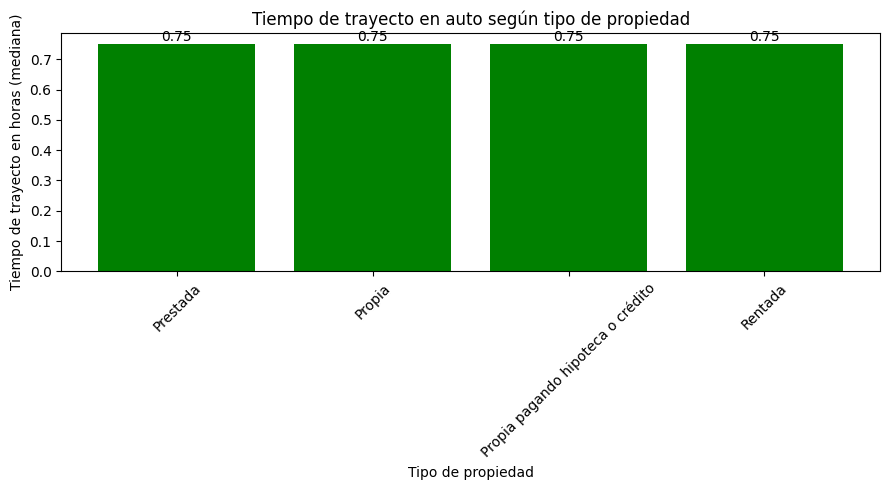

,grupo,n,W,p_valor,normal,advertencia
0,Prestada,38,0.789145,6.331571e-06,False,None
1,Propia,533,0.766076,7.577950e-27,False,None
2,Propia pagando hipoteca o crédito,62,0.872790,1.154816e-05,False,None
3,Rentada,60,0.777318,3.833239e-08,False,None


{'estadistico': 8.478657714912202,
 'p_valor': 1.547200969697194e-05,
 'homogeneidad': False}

{'prueba': 'Kruskal-Wallis',
 'n': 693,
 'estadistico': 2.645085099369685,
 'p_valor': 0.449640311811736,
 'effect_size': 0.003822377311227868,
 'magnitud': 'Trivial',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'No',
 'grupo_min_n': 38}

In [19]:
p125v1t = 'La vivienda es … '
p125v2t = 'Si el o la jefe(a) de familia utiliza el automóvil particular para ir a trabajar, ¿Cuánto tiempo le toma en promedio ir y regresar?'

valor_trayecto = {'De 30 minutos a 1 hora': 0.75, 'Menos de 30 minutos': 0.25, 'De 1 hora  a 1 hora, 30 minutos': 1.25, 'Más de 3 horas': 3.25, 'Entre 1 hora, 31 minutos a 2 horas': 1.75, 'De 2 a 3 horas': 2.5}

p125 = df[[p125v1t, p125v2t]].copy()
p125.loc[p125[p125v1t].eq("No sé"), p125v1t] = np.nan
p125[p125v2t] = p125[p125v2t].map(valor_trayecto)

ax = grafica_resumen_grupos(
    p125, p125v1t, p125v2t,
    estadistico="mediana",
    titulo="Tiempo de trayecto en auto según tipo de propiedad",
    xlabel="Tipo de propiedad",
    ylabel="Tiempo de trayecto en horas (mediana)",
    rotacion=45
)

for barra in ax.patches:
    barra.set_facecolor("green")

guardar_y_mostrar("P14", 1)


supuestos_grupos_p125 = normalidad_y_levene_por_grupos(p125, p125v1t, p125v2t)
display(supuestos_grupos_p125["normalidad"])
display(supuestos_grupos_p125["levene"])

kruskal_p125 = kruskal_wallis(p125, p125v1t, p125v2t)
kruskal_p125


# 15


In [20]:
p13v1t = "La vivienda es … "
p13v2t = "Para cumplir con las restricciones por la pandemia, ¿Qué modificaciones o adaptaciones se hicieron a la vivienda y sus espacios?  | En mobiliario doméstico (camas, mesas, sillones…) y aparatos ligeros (televisor, teléfono, ventilador…)"
p13v3t = "Para cumplir con las restricciones por la pandemia, ¿Qué modificaciones o adaptaciones se hicieron a la vivienda y sus espacios?  | En instalaciones, ductos o redes (contactos eléctricos, cableado de Internet o televisión o telefonía, líneas hidrosanitaria"
p13v4t = "Para cumplir con las restricciones por la pandemia, ¿Qué modificaciones o adaptaciones se hicieron a la vivienda y sus espacios?  | En elementos constructivos (muros, pisos, techos, ventanas, puertas…)"
p13v5t = "Para cumplir con las restricciones por la pandemia, ¿Qué modificaciones o adaptaciones se hicieron a la vivienda y sus espacios?  | Ecotecnologías (ejemplos o descripción de las mismas)"

cols_modificaciones = [p13v2t, p13v3t, p13v4t, p13v5t]
p13 = df[[p13v1t] + cols_modificaciones].copy()
p13.loc[p13[p13v1t].eq("No sé"), p13v1t] = np.nan
p13["hizo_alguna_modificacion"] = (p13[cols_modificaciones] != "No realizó modificaciones en este rubro").any(axis=1)
p13["hizo_alguna_modificacion"] = p13["hizo_alguna_modificacion"].map({True: "Sí", False: "No"})

tabla_p13 = pd.crosstab(p13[p13v1t], p13["hizo_alguna_modificacion"])
display(tabla_p13)
chi2_p13 = chi_cuadrada(p13, p13v1t, "hizo_alguna_modificacion")
chi2_p13


hizo_alguna_modificacion,No,Sí
La vivienda es …,,
Prestada,67,13
Propia,768,157
Propia pagando hipoteca o crédito,75,17
Rentada,153,27


{'prueba': 'Chi-cuadrada',
 'n': 1277,
 'estadistico': 0.6394034350760883,
 'p_valor': 0.8873555258325531,
 'effect_size': 0.022376493621174342,
 'magnitud': 'Trivial',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'No',
 'esperadas_pct_menor_5': 0.0,
 'esperada_min': 13.406421299921691,
 'gl': 3}

# 16

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P16_grafica_01.png


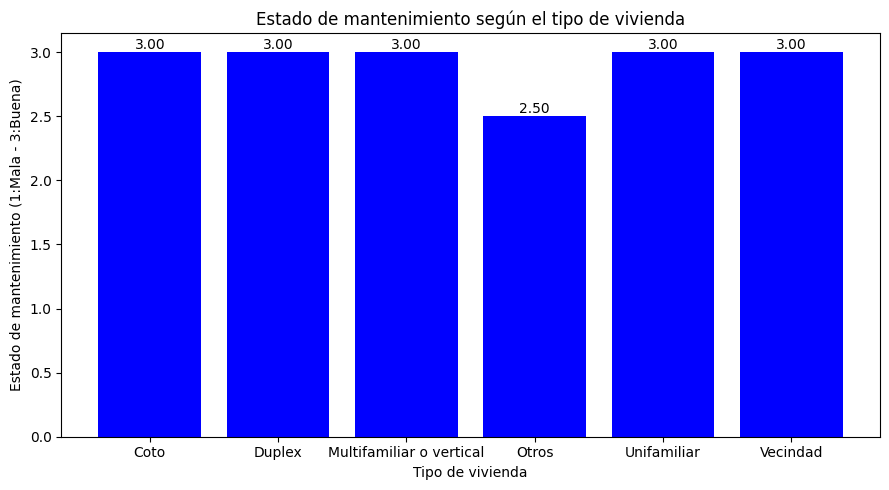

,grupo,n,W,p_valor,normal,advertencia
0,Coto,13,0.445677,4.025130e-06,False,None
1,Duplex,36,0.696510,2.494721e-07,False,None
2,Multifamiliar o vertical,312,0.644985,5.596950e-25,False,None
3,Otros,8,0.797582,2.696777e-02,False,None
4,Unifamiliar,916,0.675957,1.526837e-38,False,None
5,Vecindad,3,NaN,NaN,None,Grupo constante


{'prueba': 'Kruskal-Wallis',
 'n': 1288,
 'estadistico': 7.289608030517471,
 'p_valor': 0.1999773034250604,
 'effect_size': 0.005664031103743178,
 'magnitud': 'Trivial',
 'estado': 'Válida con advertencia',
 'advertencia': 'grupo menor n=3',
 'significativo': 'No',
 'grupo_min_n': 3}

In [21]:
p14v1t="La vivienda es… "
p14v2t="¿Cómo describe al estado de mantenimiento de esta vivienda? "
p14=df[[p14v1t,p14v2t]].copy()

valor_estado = {
    "Buena (Pintura reciente, enjarre, vidrios y herrería completa)": 3,
    "Regular (Algunos elementos faltantes)": 2,
    "Mala (Deterioro evidente en varios componentes, grafiti, vandalismo desatendido)": 1
}
p14[p14v2t] = p14[p14v2t].map(valor_estado)

p14


ax = grafica_resumen_grupos(
    p14, p14v1t, p14v2t,
    estadistico="mediana",
    titulo="Estado de mantenimiento según el tipo de vivienda",
    xlabel="Tipo de vivienda",
    ylabel="Estado de mantenimiento (1:Mala - 3:Buena)",
)

for barra in ax.patches:
    barra.set_facecolor("blue")

guardar_y_mostrar("P16", 1)



supuestos_grupos_p14 = normalidad_y_levene_por_grupos(p14, p14v1t, p14v2t)
display(supuestos_grupos_p14["normalidad"])
supuestos_grupos_p14["levene"]


kruskal_p14 = kruskal_wallis(p14, p14v1t, p14v2t)
kruskal_p14


# 17


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P17_grafica_01.png


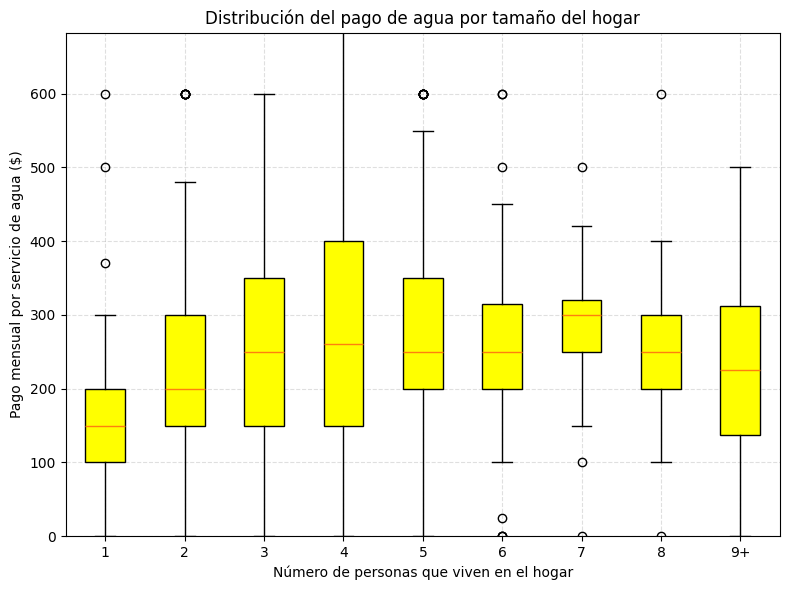

{'spearman': {'prueba': 'Spearman',
  'n': 1283,
  'estadistico': 0.15958907005757464,
  'p_valor': 9.050755723517565e-09,
  'effect_size': 0.15958907005757464,
  'magnitud': 'Débil',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.1513779220594745,
 'mutual_information': 0.05971483631636865}

In [22]:
p15v1t="¿Cuántas personas viven en este hogar?"
p15v2t="¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Agua"

p15 = df[[p15v1t,p15v2t]].copy()

p15[p15v1t] = pd.to_numeric(
    p15[p15v1t].map(lambda v: 9.1 if v == "9+" else v),
    errors="coerce"
)
p15 = p15[p15[p15v2t] <= 100000]


p15


ax = grafica_boxplot_por_categoria(
    p15, p15v1t, p15v2t,
    orden=[1, 2, 3, 4, 5, 6, 7, 8, 9.1],
    etiquetas=["1", "2", "3", "4", "5", "6", "7", "8", "9+"],
    titulo="Distribución del pago de agua por tamaño del hogar",
    xlabel="Número de personas que viven en el hogar",
    ylabel="Pago mensual por servicio de agua ($)",
)

for caja in ax.patches:
    caja.set_facecolor("yellow")

guardar_y_mostrar("P17", 1)

supuestos_p15 = evaluar_supuestos_parametricos(p15, p15v1t, p15v2t)
supuestos_p15


if not supuestos_p15["todos_cumplen"]:
    pruebas_p15 = pruebas_no_parametricas(p15, p15v1t, p15v2t)
    display(pruebas_p15)


# 18


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P18_grafica_01.png


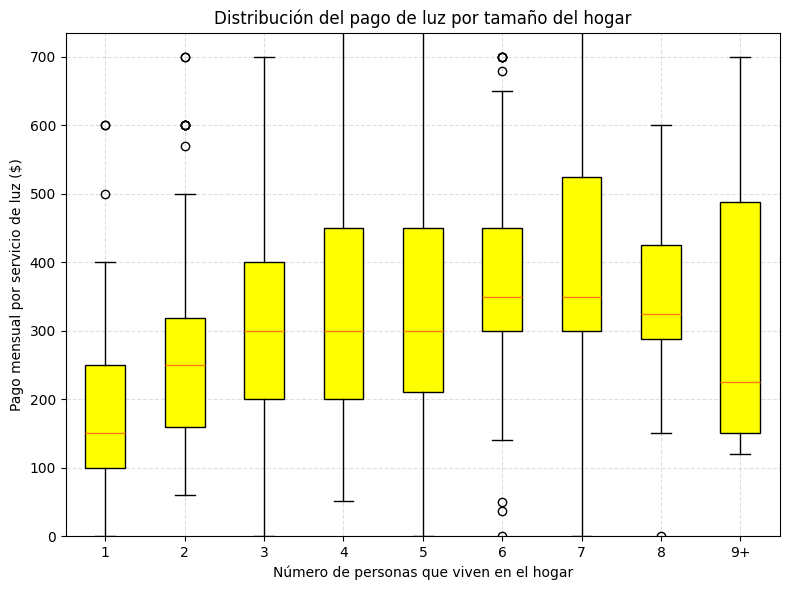

{'spearman': {'prueba': 'Spearman',
  'n': 1286,
  'estadistico': 0.24561647583217205,
  'p_valor': 4.009991377185879e-19,
  'effect_size': 0.24561647583217205,
  'magnitud': 'Débil',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.2142534593544396,
 'mutual_information': 0.06741739339398523}

In [23]:
p16v1t="¿Cuántas personas viven en este hogar?"
p16v2t="¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Luz"

p16 = df[[p16v1t,p16v2t]].copy()

p16[p16v1t] = pd.to_numeric(
    p16[p16v1t].map(lambda v: 9.1 if v == "9+" else v),
    errors="coerce"
)
p16 = p16[p16[p16v2t] <= 100000]

p16


ax = grafica_boxplot_por_categoria(
    p16, p16v1t, p16v2t,
    orden=[1, 2, 3, 4, 5, 6, 7, 8, 9.1],
    etiquetas=["1", "2", "3", "4", "5", "6", "7", "8", "9+"],
    titulo="Distribución del pago de luz por tamaño del hogar",
    xlabel="Número de personas que viven en el hogar",
    ylabel="Pago mensual por servicio de luz ($)",
)

for caja in ax.patches:
    caja.set_facecolor("yellow")

guardar_y_mostrar("P18", 1)


supuestos_p16 = evaluar_supuestos_parametricos(p16, p16v1t, p16v2t)
supuestos_p16


if not supuestos_p16["todos_cumplen"]:
    pruebas_p16 = pruebas_no_parametricas(p16, p16v1t, p16v2t)
    display(pruebas_p16)


# 19


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P19_grafica_01.png


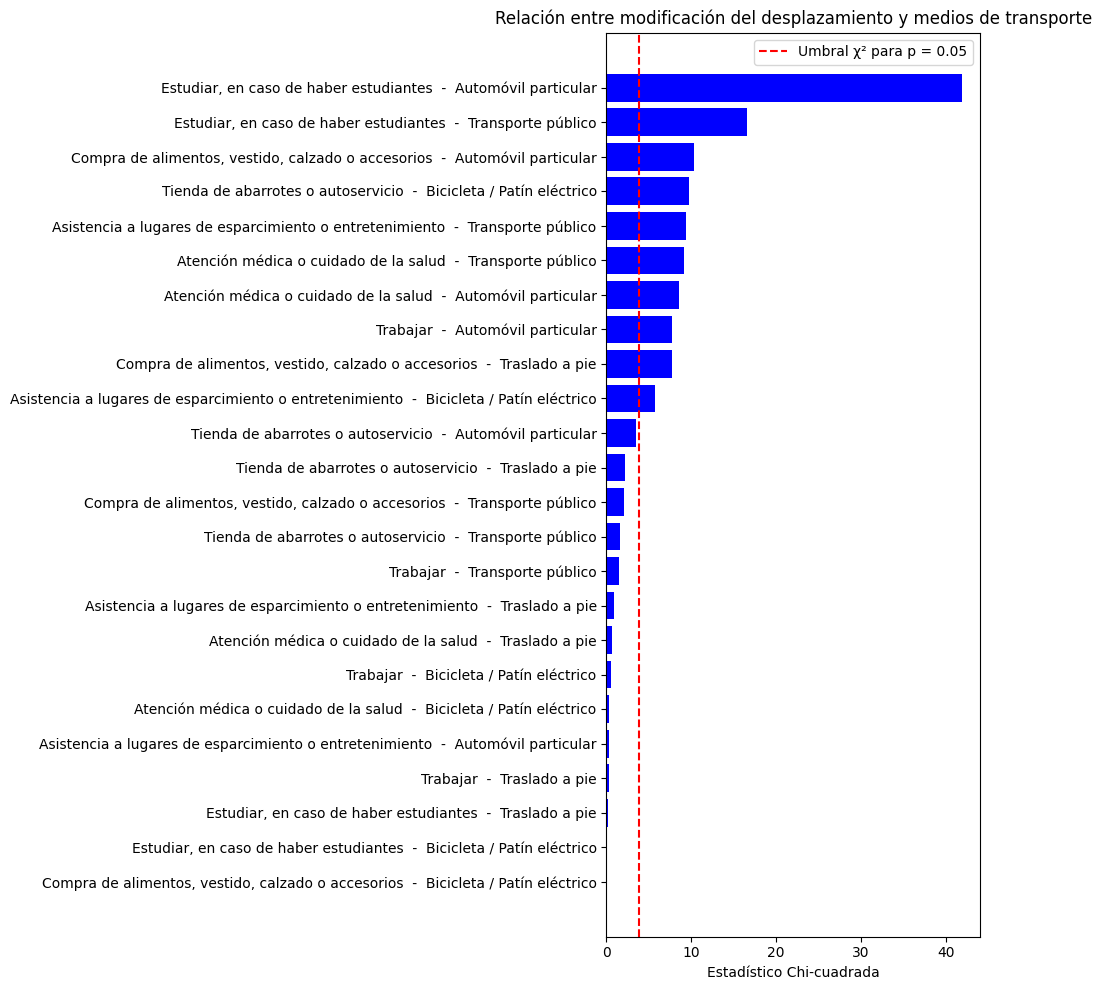

In [24]:
p17v1t = "¿Durante la pandemia modificaron alguna de estas opciones de desplazamiento?"

p17v2t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Trabajar | Automóvil particular"
p17v3t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Trabajar | Transporte público"
p17v4t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Trabajar | Traslado a pie"
p17v5t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Trabajar | Bicicleta / Patín eléctrico"

p17v6t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Estudiar, en caso de haber estudiantes | Automóvil particular"
p17v7t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Estudiar, en caso de haber estudiantes | Transporte público"
p17v8t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Estudiar, en caso de haber estudiantes | Traslado a pie"
p17v9t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Estudiar, en caso de haber estudiantes | Bicicleta / Patín eléctrico"

p17v10t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Compra de alimentos, vestido, calzado o accesorios | Automóvil particular"
p17v11t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Compra de alimentos, vestido, calzado o accesorios | Transporte público"
p17v12t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Compra de alimentos, vestido, calzado o accesorios | Traslado a pie"
p17v13t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Compra de alimentos, vestido, calzado o accesorios | Bicicleta / Patín eléctrico"

p17v14t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Asistencia a lugares de esparcimiento o entretenimiento | Automóvil particular"
p17v15t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Asistencia a lugares de esparcimiento o entretenimiento | Transporte público"
p17v16t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Asistencia a lugares de esparcimiento o entretenimiento | Traslado a pie"
p17v17t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Asistencia a lugares de esparcimiento o entretenimiento | Bicicleta / Patín eléctrico"

p17v18t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Atención médica o cuidado de la salud | Automóvil particular"
p17v19t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Atención médica o cuidado de la salud | Transporte público"
p17v20t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Atención médica o cuidado de la salud | Traslado a pie"
p17v21t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Atención médica o cuidado de la salud | Bicicleta / Patín eléctrico"

p17v22t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Tienda de abarrotes o autoservicio | Automóvil particular"
p17v23t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Tienda de abarrotes o autoservicio | Transporte público"
p17v24t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Tienda de abarrotes o autoservicio | Traslado a pie"
p17v25t = "¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte?  | Tienda de abarrotes o autoservicio | Bicicleta / Patín eléctrico"

cols = [p17v1t, p17v2t, p17v3t, p17v4t, p17v5t, p17v6t, p17v7t, p17v8t, p17v9t, p17v10t, 
        p17v11t, p17v12t, p17v13t, p17v14t, p17v15t, p17v16t, p17v17t, p17v18t, p17v19t, 
        p17v20t, p17v21t, p17v22t, p17v23t, p17v24t, p17v25t]

p17=df[cols]
p17


col_dependiente = p17v1t
cols_independientes = [p17v2t, p17v3t, p17v4t, p17v5t, p17v6t, p17v7t, p17v8t, p17v9t, p17v10t,
                       p17v11t, p17v12t, p17v13t, p17v14t, p17v15t, p17v16t, p17v17t, p17v18t, p17v19t,
                       p17v20t, p17v21t, p17v22t, p17v23t, p17v24t, p17v25t]

p17r = pd.DataFrame([
    {"variable": col, **chi_cuadrada(p17, col, col_dependiente)}
    for col in cols_independientes
]).sort_values("p_valor")
p17r


fig, ax = plt.subplots(figsize=(10, 10))

p17r = p17r.copy()
p17r["etiqueta"] = (
    p17r["variable"]
    .str.split("|")
    .str[-2:]
    .str.join(" - ")
    .str.strip()
)

p17r = p17r.sort_values("estadistico", ascending=True)

ax.barh(
    p17r["etiqueta"],
    p17r["estadistico"],
    color="blue"

)

umbral_chi2 = stats.chi2.ppf(0.95, df=1)

ax.axvline(
    umbral_chi2,
    color="red",
    linestyle="--",
    label="Umbral χ² para p = 0.05"
)

ax.set_xlabel("Estadístico Chi-cuadrada")
ax.set_title(
    "Relación entre modificación del desplazamiento y medios de transporte"
)

ax.legend()

plt.tight_layout()
guardar_y_mostrar("P19", 1)

# 20


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P20_grafica_01.png


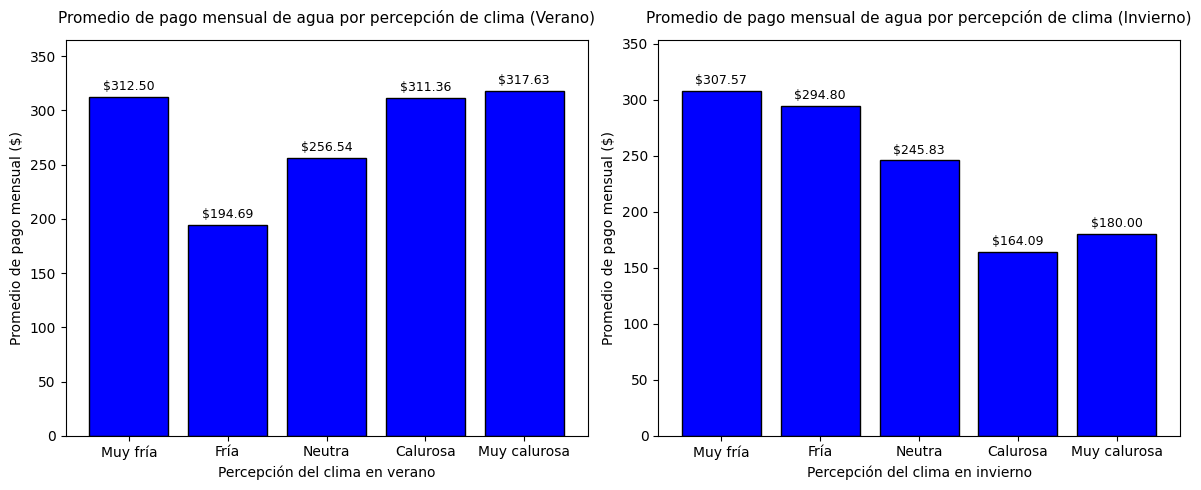

{'spearman': {'prueba': 'Spearman',
  'n': 1283,
  'estadistico': 0.10003585123873016,
  'p_valor': 0.00033233658763692135,
  'effect_size': 0.10003585123873016,
  'magnitud': 'Débil',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.11162760139194075,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1283,
  'estadistico': 23.35428826535181,
  'p_valor': 0.00010757272417553991,
  'effect_size': 0.018217073529915608,
  'magnitud': 'Pequeño',
  'estado': 'Válida con advertencia',
  'advertencia': 'grupo menor n=4',
  'significativo': 'Sí',
  'grupo_min_n': 4}}

{'spearman': {'prueba': 'Spearman',
  'n': 1283,
  'estadistico': -0.10764770659391067,
  'p_valor': 0.00011186340929358834,
  'effect_size': -0.10764770659391067,
  'magnitud': 'Débil',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.10483056159368694,
 'mutual_information': 0.039862225487018677,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1283,
  'estadistico': 26.099828458190018,
  'p_valor': 3.021119708110212e-05,
  'effect_size': 0.02035868054461,
  'magnitud': 'Pequeño',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí',
  'grupo_min_n': 6}}

In [25]:
p18v1t="¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Agua"
p18v2t="De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno?  | En verano"
p18v3t="De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno?  | En invierno"

valor_clima={
    "Muy fría":1,
    "Fría":2,
    "Neutra":3,
    "Calurosa":4,
    "Muy calurosa":5,
}
p18=df[[p18v1t,p18v2t,p18v3t]].copy()

p18["clm_ord_enc_verano"]=p18[p18v2t].map(valor_clima)
p18["clm_ord_enc_invierno"]=p18[p18v3t].map(valor_clima)

p18 = p18[p18[p18v1t] <= 100000]

p18


orden_clima = ["Muy fría", "Fría", "Neutra", "Calurosa", "Muy calurosa"]

promedio_agua_verano = p18.groupby(p18v2t)[p18v1t].mean().reindex(orden_clima)
promedio_agua_invierno = p18.groupby(p18v3t)[p18v1t].mean().reindex(orden_clima)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(
    promedio_agua_verano.index,
    promedio_agua_verano.values,
    color="blue",
    edgecolor="black",
)

for i, v in enumerate(promedio_agua_verano.values):
  if pd.notna(v):
    ax1.text(
        i,
        v + (promedio_agua_verano.max() * 0.02),
        f"${v:.2f}",
        ha="center",
        fontsize=9,
    )

ax1.set_title(
    "Promedio de pago mensual de agua por percepción de clima (Verano)",
    fontsize=11,
    pad=12,
)
ax1.set_xlabel("Percepción del clima en verano", fontsize=10)
ax1.set_ylabel("Promedio de pago mensual ($)", fontsize=10)
ax1.set_ylim(0, promedio_agua_verano.max() * 1.15)
plt.setp(ax1.get_xticklabels(), rotation=0)

ax2.bar(
    promedio_agua_invierno.index,
    promedio_agua_invierno.values,
    color="blue",
    edgecolor="black",
)

for i, v in enumerate(promedio_agua_invierno.values):
  if pd.notna(v):
    ax2.text(
        i,
        v + (promedio_agua_invierno.max() * 0.02),
        f"${v:.2f}",
        ha="center",
        fontsize=9,
    )

ax2.set_title(
    "Promedio de pago mensual de agua por percepción de clima (Invierno)",
    fontsize=11,
    pad=12,
)
ax2.set_xlabel("Percepción del clima en invierno", fontsize=10)
ax2.set_ylabel("Promedio de pago mensual ($)", fontsize=10)
ax2.set_ylim(0, promedio_agua_invierno.max() * 1.15)
plt.setp(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
guardar_y_mostrar("P20", 1)


supuestos_p18_verano = evaluar_supuestos_parametricos(p18, "clm_ord_enc_verano", p18v1t)
supuestos_p18_verano


if not supuestos_p18_verano["todos_cumplen"]:
    pruebas_p18_verano = pruebas_no_parametricas(
        p18, p18v1t, "clm_ord_enc_verano"
    )
    pruebas_p18_verano["kruskal_wallis"] = kruskal_wallis(
        p18, p18v2t, p18v1t
    )
    display(pruebas_p18_verano)


supuestos_p18_invierno = evaluar_supuestos_parametricos(p18, "clm_ord_enc_invierno", p18v1t)
supuestos_p18_invierno


if not supuestos_p18_invierno["todos_cumplen"]:
    pruebas_p18_invierno = pruebas_no_parametricas(
        p18, p18v1t, "clm_ord_enc_invierno"
    )
    pruebas_p18_invierno["kruskal_wallis"] = kruskal_wallis(
        p18, p18v3t, p18v1t
    )
    display(pruebas_p18_invierno)


# 21


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P21_grafica_01.png


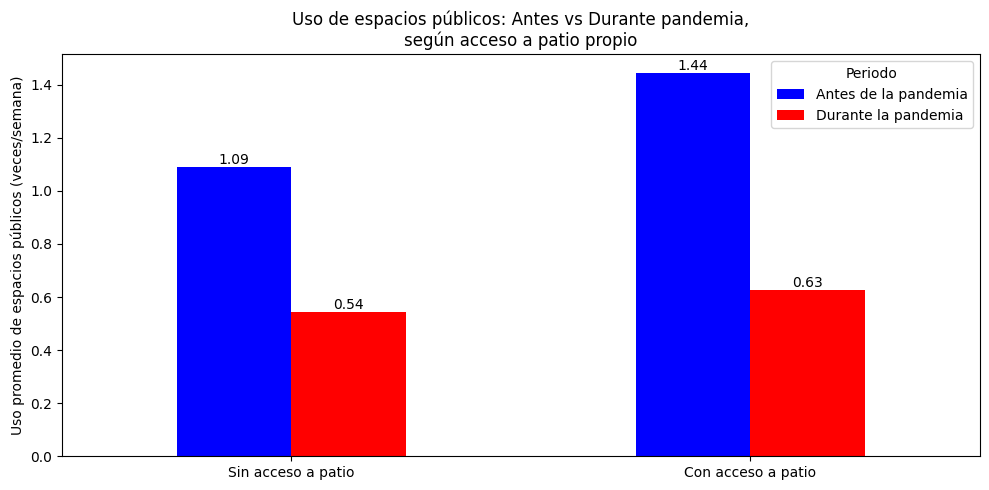

{'spearman': {'prueba': 'Spearman',
  'n': 1050,
  'estadistico': 0.03318208165907034,
  'p_valor': 0.28271628355561496,
  'effect_size': 0.03318208165907034,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'No'},
 'distance_correlation': 0.06156757621601804,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1050,
  'estadistico': 1.1550020198473132,
  'p_valor': 0.28250449442004444,
  'effect_size': 0.001101050543229088,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'No',
  'grupo_min_n': 155}}

{'spearman': {'prueba': 'Spearman',
  'n': 1040,
  'estadistico': 0.06093066141590481,
  'p_valor': 0.049481738066405864,
  'effect_size': 0.06093066141590481,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.045304297816805846,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1040,
  'estadistico': 3.8573347751015423,
  'p_valor': 0.049528947147544425,
  'effect_size': 0.0037125455005789627,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí',
  'grupo_min_n': 155}}

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P21_grafica_02.png


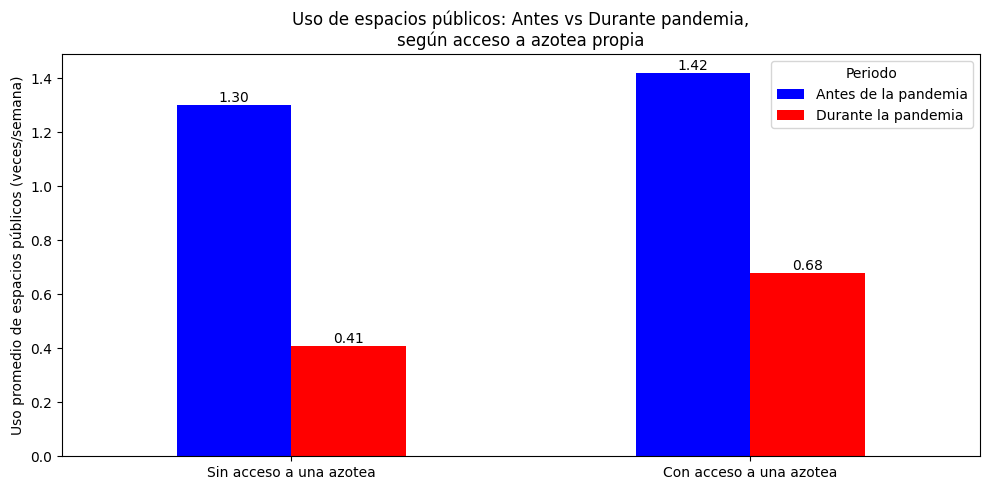

{'spearman': {'prueba': 'Spearman',
  'n': 1050,
  'estadistico': -0.0039276859402405705,
  'p_valor': 0.8988450548529098,
  'effect_size': -0.0039276859402405705,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'No'},
 'distance_correlation': 0.03454162414260453,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1050,
  'estadistico': 0.016182625971031237,
  'p_valor': 0.8987734384146585,
  'effect_size': 1.5426716845596985e-05,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'No',
  'grupo_min_n': 248}}

{'spearman': {'prueba': 'Spearman',
  'n': 1040,
  'estadistico': 0.08422680951029679,
  'p_valor': 0.006571814498779097,
  'effect_size': 0.08422680951029679,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.08290526996539171,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1040,
  'estadistico': 7.3708275024551115,
  'p_valor': 0.006629042197464881,
  'effect_size': 0.0070941554402840345,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí',
  'grupo_min_n': 245}}

In [26]:
p19v1t = "¿La vivienda tiene acceso a…?  | Un patio propio"
p19v2t = "¿La vivienda tiene acceso a…?  | Una azotea propia"
p19v3t = "Antes de la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio? "
p19v4t = "Durante la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio?"

valor_uso = {
    "No los usabamos": 0,
    "Una vez a la semana o menos": 0.8,
    "No hay espacios urbanos y/o áreas verdes en el barrio": None,
    "Dos veces por semana": 2,
    "Diario": 7,
    "No sé / no recuerdo": None
}

p19 = df[[p19v1t, p19v2t, p19v3t, p19v4t]].copy()

p19["uso_prepandemia_enc"] = p19[p19v3t].map(valor_uso)
p19["uso_pandemia_enc"] = p19[p19v4t].map(valor_uso)

p19["acceso_patio_enc"] = p19[p19v1t].map({"Sí": 1, "No": 0})
p19["acceso_azotea_enc"] = p19[p19v2t].map({"Sí": 1, "No": 0})

# --- Patio: tc19 ---
tc19 = p19.groupby("acceso_patio_enc")[["uso_prepandemia_enc", "uso_pandemia_enc"]].mean()
tc19.index = ["Sin acceso a patio", "Con acceso a patio"]
tc19.columns = ["Antes de la pandemia", "Durante la pandemia"]

fig, ax = plt.subplots(figsize=(10, 5))
tc19.plot(kind="bar", ax=ax, color=["blue", "red"])
ax.set_ylabel("Uso promedio de espacios públicos (veces/semana)")
ax.set_title("Uso de espacios públicos: Antes vs Durante pandemia,\nsegún acceso a patio propio")
plt.xticks(rotation=0)
ax.legend(title="Periodo")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
guardar_y_mostrar("P21", 1)

pruebas_p19_patio_antes = pruebas_no_parametricas(
    p19, "acceso_patio_enc", "uso_prepandemia_enc", col_categorica=p19v1t
)
display(pruebas_p19_patio_antes)

pruebas_p19_patio_durante = pruebas_no_parametricas(
    p19, "acceso_patio_enc", "uso_pandemia_enc", col_categorica=p19v1t
)
display(pruebas_p19_patio_durante)

tc19b = p19.groupby("acceso_azotea_enc")[["uso_prepandemia_enc", "uso_pandemia_enc"]].mean()
tc19b.index = ["Sin acceso a una azotea", "Con acceso a una azotea"]
tc19b.columns = ["Antes de la pandemia", "Durante la pandemia"]

fig, ax = plt.subplots(figsize=(10, 5))
tc19b.plot(kind="bar", ax=ax, color=["blue", "red"])
ax.set_ylabel("Uso promedio de espacios públicos (veces/semana)")
ax.set_title("Uso de espacios públicos: Antes vs Durante pandemia,\nsegún acceso a azotea propia")
plt.xticks(rotation=0)
ax.legend(title="Periodo")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
guardar_y_mostrar("P21", 2)

pruebas_p19_azotea_antes = pruebas_no_parametricas(
    p19, "acceso_azotea_enc", "uso_prepandemia_enc", col_categorica=p19v2t
)
display(pruebas_p19_azotea_antes)

pruebas_p19_azotea_durante = pruebas_no_parametricas(
    p19, "acceso_azotea_enc", "uso_pandemia_enc", col_categorica=p19v2t
)
display(pruebas_p19_azotea_durante)


# 22

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P22_grafica_01.png


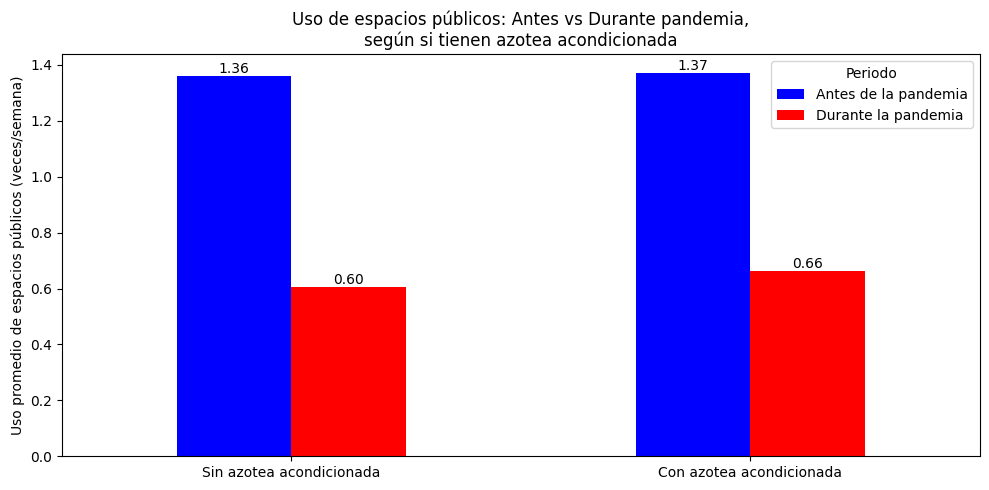

{'spearman': {'prueba': 'Spearman',
  'n': 1050,
  'estadistico': 0.05526103378955547,
  'p_valor': 0.07347046140475953,
  'effect_size': 0.05526103378955547,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'No'},
 'distance_correlation': 0.04734498362457677,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1050,
  'estadistico': 3.2034171664094018,
  'p_valor': 0.0734845809696869,
  'effect_size': 0.0030537818554903736,
  'magnitud': 'Trivial',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'No',
  'grupo_min_n': 329}}

{'spearman': {'prueba': 'Spearman',
  'n': 1040,
  'estadistico': 0.11954594610489619,
  'p_valor': 0.0001113303175049697,
  'effect_size': 0.11954594610489619,
  'magnitud': 'Débil',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí'},
 'distance_correlation': 0.0916122142811959,
 'mutual_information': 0.0,
 'kruskal_wallis': {'prueba': 'Kruskal-Wallis',
  'n': 1040,
  'estadistico': 14.848591326089585,
  'p_valor': 0.00011649504282890633,
  'effect_size': 0.014291233230115096,
  'magnitud': 'Pequeño',
  'estado': 'Válida',
  'advertencia': None,
  'significativo': 'Sí',
  'grupo_min_n': 329}}

In [27]:
p20v1t = "¿La azotea de su casa está acondicionada para ser utilizada como terraza, espacio de trabajo, lugar de esparcimiento, etc.? "
p20v2t = "Antes de la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio? "
p20v3t = "Durante la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio?"

p20 = df[[p20v1t, p20v2t, p20v3t]].copy()
p20["azotea_acondicionada_enc"] = p20[p20v1t].map({"Sí": 1, "No": 0})
p20["uso_prepandemia_enc"] = p20[p20v2t].map(valor_uso)
p20["uso_pandemia_enc"] = p20[p20v3t].map(valor_uso)

p20c = p20.dropna(subset=["azotea_acondicionada_enc", "uso_prepandemia_enc", "uso_pandemia_enc"]).copy()

tc20 = p20c.groupby("azotea_acondicionada_enc")[["uso_prepandemia_enc", "uso_pandemia_enc"]].mean()
tc20.index = ["Sin azotea acondicionada", "Con azotea acondicionada"]
tc20.columns = ["Antes de la pandemia", "Durante la pandemia"]

fig, ax = plt.subplots(figsize=(10, 5))
tc20.plot(kind="bar", ax=ax, color=["blue", "red"])
ax.set_ylabel("Uso promedio de espacios públicos (veces/semana)")
ax.set_title("Uso de espacios públicos: Antes vs Durante pandemia,\nsegún si tienen azotea acondicionada")
plt.xticks(rotation=0)
ax.legend(title="Periodo")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
guardar_y_mostrar("P22", 1)

pruebas_p20_antes = pruebas_no_parametricas(
    p20, "azotea_acondicionada_enc", "uso_prepandemia_enc", col_categorica=p20v1t
)
display(pruebas_p20_antes)

pruebas_p20_durante = pruebas_no_parametricas(
    p20, "azotea_acondicionada_enc", "uso_pandemia_enc", col_categorica=p20v1t
)
display(pruebas_p20_durante)


# 23


Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P23_grafica_01.png


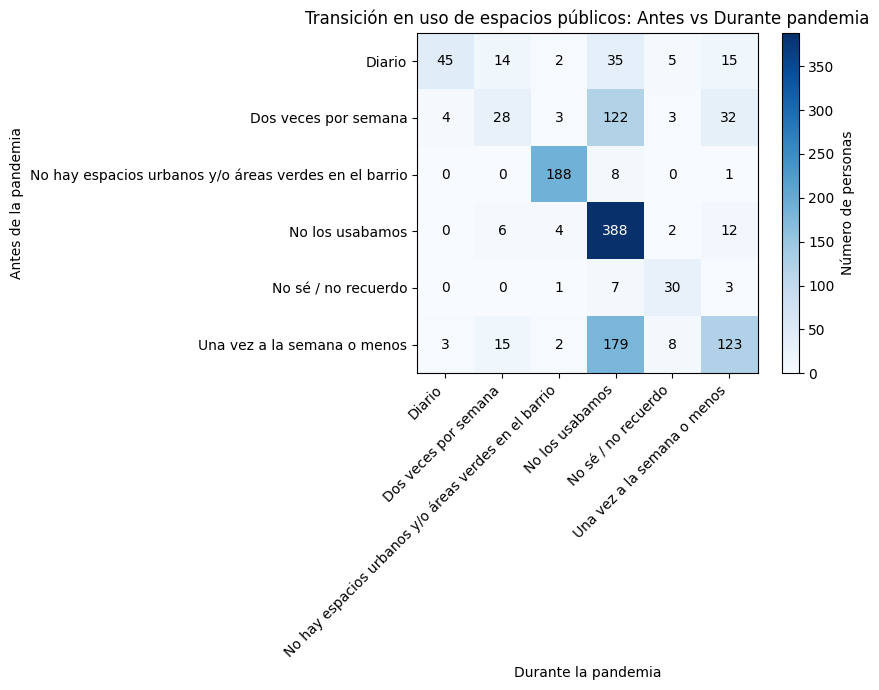

Gráfica guardada: /home/joseluisalmendarezgonzalez/Desktop/PI/graficas/P23_grafica_02.png


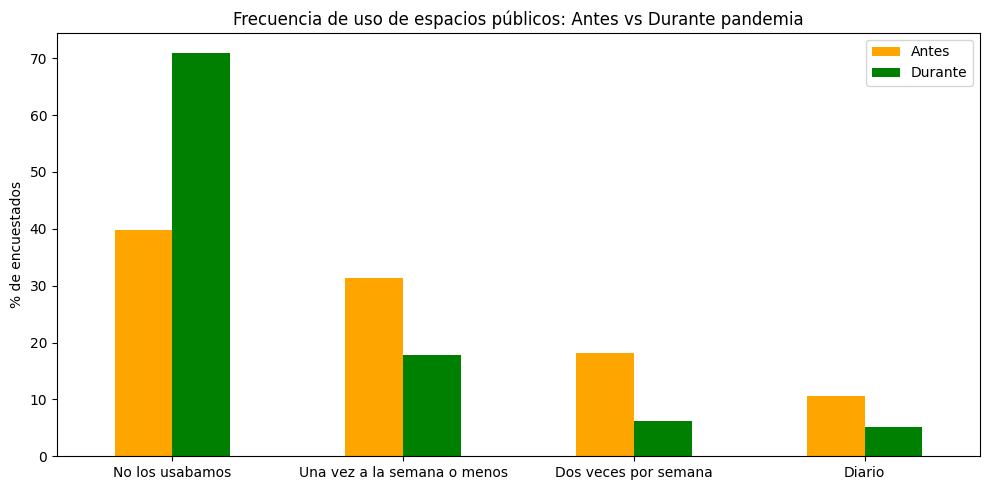

In [28]:
p21v1t = "Antes de la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio? "
p21v2t = "Durante la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio?"

valor_uso = {
    "No los usabamos": 0,
    "Una vez a la semana o menos": 0.8,
    "No hay espacios urbanos y/o áreas verdes en el barrio": None,
    "Dos veces por semana": 2,
    "Diario": 7,
    "No sé / no recuerdo": None,
}

p21 = df[[p21v1t, p21v2t]].copy()
p21["uso_prepandemia_enc"] = p21[p21v1t].map(valor_uso)
p21["uso_pandemia_enc"] = p21[p21v2t].map(valor_uso)

p21c = p21.dropna(subset=["uso_prepandemia_enc", "uso_pandemia_enc"])

p21c


matriz_transicion = pd.crosstab(p21[p21v1t], p21[p21v2t])

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matriz_transicion.values, cmap="Blues")

ax.set_xticks(range(len(matriz_transicion.columns)))
ax.set_xticklabels(matriz_transicion.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matriz_transicion.index)))
ax.set_yticklabels(matriz_transicion.index)

# Agregar el número dentro de cada celda
for i in range(matriz_transicion.shape[0]):
    for j in range(matriz_transicion.shape[1]):
        valor = matriz_transicion.values[i, j]
        color_texto = "white" if valor > matriz_transicion.values.max() / 2 else "black"
        ax.text(j, i, str(valor), ha="center", va="center", color=color_texto)

ax.set_xlabel("Durante la pandemia")
ax.set_ylabel("Antes de la pandemia")
ax.set_title("Transición en uso de espacios públicos: Antes vs Durante pandemia")
fig.colorbar(im, ax=ax, label="Número de personas")
plt.tight_layout()
guardar_y_mostrar("P23", 1)


wilcoxon_p21 = wilcoxon_pareado(p21c, "uso_prepandemia_enc", "uso_pandemia_enc")
wilcoxon_p21


conteo_antes = p21c[p21v1t].value_counts(normalize=True) * 100
conteo_durante = p21c[p21v2t].value_counts(normalize=True) * 100

categorias_validas = [k for k, v in valor_uso.items() if v is not None]

comparacion = pd.DataFrame(
    {"Antes": conteo_antes, "Durante": conteo_durante}
).reindex(categorias_validas)

fig, ax = plt.subplots(figsize=(10, 5))

comparacion.plot(kind="bar", ax=ax, color=["orange", "green"])

ax.set_ylabel("% de encuestados")
ax.set_title("Frecuencia de uso de espacios públicos: Antes vs Durante pandemia")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()

guardar_y_mostrar("P23", 2)


In [29]:
wilcoxon_p21

{'prueba': 'Wilcoxon',
 'n': 1021,
 'estadistico': 8874.5,
 'p_valor': 1.2969052110109097e-50,
 'significativo': 'Sí',
 'estado': 'Válida'}

# 24


In [30]:
p22v1t="¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Baños completos"
p22v2t="¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Medio baño"
p22v3t="¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Agua"

p22=df[[p22v1t,p22v2t,p22v3t]].copy()

p22[p22v1t] = pd.to_numeric(
    p22[p22v1t].map(lambda v: 0 if v == "0 (No)" else v),
    errors="coerce",
)
p22[p22v2t] = pd.to_numeric(
    p22[p22v2t].map(lambda v: 0 if v == "0 (No)" else v),
    errors="coerce",
)

p22["medios_baños_equivalentes"] = p22[p22v2t] * 0.5

p22 = p22[p22[p22v3t] <= 100000]

p22["total_baños"]=p22[p22v1t]+ p22["medios_baños_equivalentes"]

p22


supuestos_p22_completos = evaluar_supuestos_parametricos(p22, p22v1t, p22v3t)
supuestos_p22_completos


supuestos_p22_medios = evaluar_supuestos_parametricos(p22, p22v2t, p22v3t)
supuestos_p22_medios


supuestos_p22_total = evaluar_supuestos_parametricos(p22, "total_baños", p22v3t)
supuestos_p22_total


display(spearman(p22, p22v1t, p22v3t))
display(spearman(p22, p22v2t, p22v3t))
display(spearman(p22, "total_baños", p22v3t))


modelo_q22 = regresion_cuantil(
    p22, p22v3t, [p22v1t, p22v2t], q=0.5
)
modelo_q22.summary()


{'prueba': 'Spearman',
 'n': 1283,
 'estadistico': 0.15720610980015523,
 'p_valor': 1.5075017376369326e-08,
 'effect_size': 0.15720610980015523,
 'magnitud': 'Débil',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'Sí'}

{'prueba': 'Spearman',
 'n': 1283,
 'estadistico': 0.03526750366165038,
 'p_valor': 0.20680210363194762,
 'effect_size': 0.03526750366165038,
 'magnitud': 'Trivial',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'No'}

{'prueba': 'Spearman',
 'n': 1283,
 'estadistico': 0.12076170222489875,
 'p_valor': 1.4429117216415263e-05,
 'effect_size': 0.12076170222489875,
 'magnitud': 'Débil',
 'estado': 'Válida',
 'advertencia': None,
 'significativo': 'Sí'}

<class 'statsmodels.iolib.summary.Summary'>
"""
                                                        QuantReg Regression Results                                                         
============================================================================================================================================
Dep. Variable:     ¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Agua   Pseudo R-squared:             0.005851
Model:                                                                                     QuantReg   Bandwidth:                       58.32
Method:                                                                               Least Squares   Sparsity:                        371.6
Date:                                                                              Sat, 15 Aug 2026   No. Observations:                 1283
Time:                                                                                      21:14:19   Df Residuals:                     1280
                                                                                                      Df Model:                            2
=============================================================================================================================================
                                                                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------
const                                                                       214.2857     12.756     16.798      0.000     189.260     239.311
¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Baños completos    35.7143      9.387      3.805      0.000      17.299      54.129
¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Medio baño         -7.1429     10.921     -0.654      0.513     -28.568      14.283
=============================================================================================================================================
"""

# Statistical Feature Analysis


In [31]:
df_limpio, catalogo, _ = preparar_encuesta(df)


# 25


In [32]:
p24v1t = 'De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno?  | En verano'
p24 = df_limpio.copy()

screening_p24 = screening_masivo(
    p24,
    catalogo,
    p24v1t,
    df_original=df,
)
guardar_screening(screening_p24, "P25")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P25_screening.xlsx


In [33]:
display(screening_p24.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno? | En invierno",ordinal,Spearman,1288,-0.406924,1.527437e-52,Sí,-0.406924,Moderado,Válida,None,0.304251,1.0
1,2.0,Ponderador,numerica_discreta,Spearman,1288,0.004231,8.794316e-01,No,0.004231,Trivial,Válida,None,0.051428,2.0
2,3.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Focos ahorradores",dicotomica,Kruskal-Wallis,1285,65.226965,6.674989e-16,Sí,0.050800,Pequeño,Válida,None,0.017730,3.0
3,4.0,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso de gel antibacterial,dicotomica,Kruskal-Wallis,1288,28.328952,1.023536e-07,Sí,0.022012,Pequeño,Válida,None,0.015520,4.0
4,5.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Focos ahorradores",dicotomica,Kruskal-Wallis,1283,26.450223,2.704172e-07,Sí,0.020632,Pequeño,Válida,None,0.009084,5.0
5,6.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Gas",numerica_continua,Spearman,1278,0.096099,5.816141e-04,Sí,0.096099,Trivial,Válida,None,0.005648,6.0
6,7.0,"¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?",ordinal,Spearman,1287,0.095022,6.417835e-04,Sí,0.095022,Trivial,Válida,None,0.005067,7.0
7,8.0,"¿Durante la pandemia, noto alguna diferencia en la cantidad del ruido en su entorno?",dicotomica,Kruskal-Wallis,1153,11.639951,6.455029e-04,Sí,0.010104,Pequeño,Válida,None,0.004803,8.0
8,9.0,¿Cómo evalúa a las condiciones o funcionamiento de los siguientes aspectos de su barrio o colonia? | Alumbrado,ordinal,Spearman,1288,-0.074591,7.404316e-03,Sí,-0.074591,Trivial,Válida,None,0.004300,9.0
9,10.0,"Durante la pandemia por COVID-19, adquirieron los siguientes servicios: | Internet",dicotomica,Kruskal-Wallis,1282,19.528954,9.908639e-06,Sí,0.015245,Pequeño,Válida,None,0.004160,10.0


# 26


In [34]:
p25v1t = 'De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno?  | En invierno'
p25 = df_limpio.copy()

screening_p25 = screening_masivo(
    p25,
    catalogo,
    p25v1t,
    df_original=df,
)
guardar_screening(screening_p25, "P26")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P26_screening.xlsx


In [35]:
display(screening_p25.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno? | En verano",ordinal,Spearman,1288,-0.406924,1.527437e-52,Sí,-0.406924,Moderado,Válida,None,0.295238,1.0
1,2.0,Ponderador,numerica_discreta,Spearman,1288,-0.037784,1.753553e-01,No,-0.037784,Trivial,Válida,None,0.012172,2.0
2,3.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Gas",numerica_continua,Spearman,1278,-0.059348,3.388651e-02,Sí,-0.059348,Trivial,Válida,None,0.009669,3.0
3,4.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Agua",numerica_continua,Spearman,1283,-0.107648,1.118634e-04,Sí,-0.107648,Débil,Válida,None,0.009101,4.0
4,5.0,"De las siguientes opciones, ¿Cuál es el tipo de material del recubrimiento de la azotea de esta vivienda?",nominal,Kruskal-Wallis,1216,6.839799,8.914887e-03,Sí,0.005629,Trivial,Válida,None,0.007549,5.0
5,6.0,"Durante las etapas fuertes del COVID-19, en su trabajo le permitieron:",nominal,Kruskal-Wallis,1288,19.021006,1.904897e-03,Sí,0.014779,Pequeño,Válida,None,0.007089,6.0
6,7.0,Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Sala comedor Ventilador de pedestal,numerica_discreta,Spearman,1288,0.027776,3.192223e-01,No,0.027776,Trivial,Válida,None,0.006193,7.0
7,8.0,¿Alguna de estas personas tiene…? | Autismo,dicotomica,Kruskal-Wallis,1288,1.805416,1.790591e-01,No,0.001403,Trivial,Válida,None,0.006193,8.0
8,9.0,"De las siguientes opciones, ¿Cuál es el tipo de material del recubrimiento de los muros de esta vivienda?",nominal,Kruskal-Wallis,1276,0.064170,8.000230e-01,No,0.000050,Trivial,Válida,None,0.006060,9.0
9,10.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Luz",numerica_continua,Spearman,1286,-0.097125,4.868994e-04,Sí,-0.097125,Trivial,Válida,None,0.004734,10.0


# 27


In [37]:
p26v1t = '¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Gas'
p26 = df_limpio.copy()

screening_p26 = screening_masivo(
    p26,
    catalogo,
    p26v1t,
    df_original=df,
)
guardar_screening(screening_p26, "P27")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P27_screening.xlsx


In [38]:
display(screening_p26.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Agua",numerica_continua,Spearman,1276,0.577138,3.303713e-114,Sí,0.577138,Fuerte,Válida,None,0.322414,1.0
1,2.0,¿Cuántas de esas personas….? | Cuentan con un trabajo remunerado que requiera más de 20 horas a la semana,numerica_topcoded,Spearman,1278,-0.035808,2.008018e-01,No,-0.035808,Trivial,Válida,None,0.079502,2.0
2,3.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Luz",numerica_continua,Spearman,1278,0.556490,8.247403e-105,Sí,0.556490,Fuerte,Válida,None,0.068761,3.0
3,4.0,Ponderador,numerica_discreta,Spearman,1278,0.076700,6.082025e-03,Sí,0.076700,Trivial,Válida,None,0.054703,4.0
4,5.0,"De las siguientes opciones, ¿Cuál es el tipo de material del recubrimiento de la azotea de esta vivienda?",nominal,Kruskal-Wallis,1206,34.834329,3.589874e-09,Sí,0.028908,Pequeño,Válida,None,0.021797,5.0
5,6.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Llaves de agua ahorradoras",dicotomica,Kruskal-Wallis,1264,88.372542,5.421820e-21,Sí,0.069970,Moderado,Válida,None,0.017583,6.0
6,7.0,"Si el o la jefe(a) de familia utiliza el automóvil particular para ir a trabajar, ¿Cuánto tiempo le toma en promedio ir y regresar?",ordinal,Spearman,695,0.156770,3.308061e-05,Sí,0.156770,Débil,Válida,None,0.014503,7.0
7,8.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Calentador solar de agua",dicotomica,Kruskal-Wallis,1260,62.603461,2.528088e-15,Sí,0.049725,Pequeño,Válida,None,0.008929,8.0
8,9.0,"¿Cuánto tiempo después de que se perdió el empleo durante la crisis del COVID se recuperó el empleo con condiciones similares (salarios, horario, prestaciones) En meses",numerica_topcoded,Spearman,236,-0.161250,1.312850e-02,Sí,-0.161250,Débil,Válida,None,0.006896,9.0
9,10.0,¿Cuántas de esas personas….? | Tienen 18 años o más,numerica_topcoded,Spearman,1278,0.264888,5.810309e-22,Sí,0.264888,Débil,Válida,None,0.006603,10.0


# 28


In [39]:
p27v1t = '¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Agua'
p27 = df_limpio.copy()

screening_p27 = screening_masivo(
    p27,
    catalogo,
    p27v1t,
    df_original=df,
)
guardar_screening(screening_p27, "P28")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P28_screening.xlsx


In [40]:
display(screening_p27.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Luz",numerica_continua,Spearman,1283,0.679676,1.265605e-174,Sí,0.679676,Fuerte,Válida,None,1.129942,1.0
1,2.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Gas",numerica_continua,Spearman,1276,0.577138,3.303713e-114,Sí,0.577138,Fuerte,Válida,None,0.092380,2.0
2,3.0,¿Cuántas de esas personas….? | Cuentan con un trabajo remunerado que requiera más de 20 horas a la semana,numerica_topcoded,Spearman,1283,0.049505,7.629998e-02,No,0.049505,Trivial,Válida,None,0.077057,3.0
3,4.0,¿Qué miembro de la familia estuvo a cargo del cuidado de o los enfermos/contagiados?,nominal,Kruskal-Wallis,491,21.837027,1.296017e-03,Sí,0.044565,Pequeño,Válida,None,0.028406,4.0
4,5.0,Ponderador,numerica_discreta,Spearman,1283,0.107544,1.135847e-04,Sí,0.107544,Débil,Válida,None,0.016512,5.0
5,6.0,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Chat de ventas o vecinales,dicotomica,Kruskal-Wallis,1283,9.948156,1.610106e-03,Sí,0.007760,Trivial,Válida,None,0.011910,6.0
6,7.0,¿De cuánto fue ese incremento aproximadamente?,numerica_continua,Spearman,412,-0.025564,6.048711e-01,No,-0.025564,Trivial,Válida,None,0.009237,7.0
7,8.0,¿Cuántos años tiene viviendo en este lugar?,numerica_topcoded,Spearman,1283,0.090465,1.179164e-03,Sí,0.090465,Trivial,Válida,None,0.007070,8.0
8,9.0,"¿De acuerdo a su percepción, cuáles de las siguientes opciones cambiaron? | Acceso cercanos a áreas verdes",ordinal,Spearman,1283,0.100556,3.092262e-04,Sí,0.100556,Débil,Válida,None,0.005825,9.0
9,10.0,¿Cuáles de las siguientes tecnologías tiene instaladas en su azotea? | Huerto,dicotomica,Kruskal-Wallis,1283,0.297448,5.854868e-01,No,0.000232,Trivial,Válida,None,0.004845,10.0


# 29


In [41]:
p28v1t = '¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios?  | Luz'
p28 = df_limpio.copy()

screening_p28 = screening_masivo(
    p28,
    catalogo,
    p28v1t,
    df_original=df,
)
guardar_screening(screening_p28, "P29")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P29_screening.xlsx


In [42]:
display(screening_p28.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Agua",numerica_continua,Spearman,1283,0.679676,1.265605e-174,Sí,0.679676,Fuerte,Válida,None,0.713742,1.0
1,2.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Gas",numerica_continua,Spearman,1278,0.556490,8.247403e-105,Sí,0.556490,Fuerte,Válida,None,0.102998,2.0
2,3.0,¿Cuántas de esas personas….? | Cuentan con un trabajo remunerado que requiera más de 20 horas a la semana,numerica_topcoded,Spearman,1286,-0.049191,7.783528e-02,No,-0.049191,Trivial,Válida,None,0.032714,3.0
3,4.0,Ponderador,numerica_discreta,Spearman,1286,0.220262,1.355735e-15,Sí,0.220262,Débil,Válida,None,0.015061,4.0
4,5.0,"¿Cuándo los usa, cuántas horas en promedio al día los enciende?",numerica_continua,Spearman,804,0.029971,3.960595e-01,No,0.029971,Trivial,Válida,None,0.011364,5.0
5,6.0,¿De cuánto fue ese incremento aproximadamente?,numerica_continua,Spearman,413,0.153227,1.790378e-03,Sí,0.153227,Débil,Válida,None,0.009876,6.0
6,7.0,"¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte? | Atención médica o cuidado de la salud | Traslado a pie",dicotomica,Kruskal-Wallis,1286,83.744576,5.630133e-20,Sí,0.065171,Moderado,Válida,None,0.005496,7.0
7,8.0,"¿Durante la pandemia, noto alguna diferencia en la cantidad del ruido en su entorno?",dicotomica,Kruskal-Wallis,1152,14.225449,1.621625e-04,Sí,0.012359,Pequeño,Válida,None,0.004367,8.0
8,9.0,¿Bajo qué esquema la compró?,nominal,Kruskal-Wallis,929,60.702618,6.585580e-14,Sí,0.065412,Moderado,Válida,None,0.004256,9.0
9,10.0,"¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte? | Compra de alimentos, vestido, calzado o accesorios | Traslado a pie",dicotomica,Kruskal-Wallis,1286,66.089434,4.309197e-16,Sí,0.051431,Pequeño,Válida,None,0.002322,10.0


# 30


In [43]:
p29v1t = 'La vivienda es… '
p29 = df_limpio.copy()

screening_p29 = screening_masivo(
    p29,
    catalogo,
    p29v1t,
    df_original=df,
)
guardar_screening(screening_p29, "P30")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P30_screening.xlsx


In [44]:
display(screening_p29.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,¿La vivienda tiene acceso a…? | Una azotea propia,dicotomica,Chi-cuadrada,1288,73.655932,1.774246e-14,No evaluable,0.239137,Débil,No evaluable,Chi² no fiable: 33.3% de celdas esperadas < 5; mínimo esperado=0.73,0.008974,1.0
1,2.0,Número de pisos sobre el nivel de banqueta,numerica_discreta,Kruskal-Wallis,1288,49.829177,1.501936e-09,Sí,0.038717,Pequeño,Válida con advertencia,grupo menor n=3,0.004701,2.0
2,3.0,"De las siguientes opciones, ¿Cuál es el tipo de material del recubrimiento de la azotea de esta vivienda?",nominal,Chi-cuadrada,1216,113.135122,8.906350e-23,No evaluable,0.305023,Moderado,No evaluable,Chi² no fiable: 33.3% de celdas esperadas < 5; mínimo esperado=1.38,0.001991,3.0
3,4.0,"¿Cuál de las siguientes frases describe mejor a la calidad del entorno urbano de su barrio o colonia? (espacio público, banquetas, arbolado, ciclovías)",nominal,Chi-cuadrada,1288,50.653397,1.768917e-03,No evaluable,0.088687,Trivial,No evaluable,Chi² no fiable: 58.3% de celdas esperadas < 5; mínimo esperado=0.11,0.001709,4.0
4,4.0,"¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte? | Trabajar | Automóvil particular",dicotomica,Chi-cuadrada,1288,29.197235,2.121044e-05,No evaluable,0.150561,Débil,No evaluable,Chi² no fiable: 33.3% de celdas esperadas < 5; mínimo esperado=1.30,0.001709,4.0
5,4.0,¿Cuántas de esas personas….? | Cuentan con un trabajo remunerado que requiera más de 20 horas a la semana,numerica_topcoded,Kruskal-Wallis,1288,13.755277,1.724098e-02,Sí,0.010688,Pequeño,Válida con advertencia,grupo menor n=3,0.001709,4.0
6,4.0,"¿De acuerdo a su percepción, cuáles de las siguientes opciones cambiaron? | Ruido",ordinal,Kruskal-Wallis,1288,8.568938,1.275431e-01,No,0.006658,Trivial,Válida con advertencia,grupo menor n=3,0.001709,4.0
7,4.0,¿Qué espacios tiene la vivienda y cuántos de cada uno? | Medio baño,numerica_discreta,Kruskal-Wallis,1288,79.862886,8.964798e-16,Sí,0.062054,Moderado,Válida con advertencia,grupo menor n=3,0.001709,4.0
8,9.0,¿Cómo evalúa a las condiciones o funcionamiento de los siguientes aspectos de su barrio o colonia? | Espacios públicos,ordinal,Kruskal-Wallis,1288,9.974447,7.596253e-02,No,0.007750,Trivial,Válida con advertencia,grupo menor n=3,0.001564,9.0
9,10.0,¿Cómo evalúa a las condiciones o funcionamiento de los siguientes aspectos de su barrio o colonia? | Recipientes para residuos,ordinal,Kruskal-Wallis,1288,56.079973,7.824163e-11,Sí,0.043574,Pequeño,Válida con advertencia,grupo menor n=3,0.001409,10.0


# 31


In [45]:
p30v1t = 'La vivienda es … '
p30 = df_limpio.copy()

screening_p30 = screening_masivo(
    p30,
    catalogo,
    p30v1t,
    df_original=df,
)
guardar_screening(screening_p30, "P31")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P31_screening.xlsx


In [46]:
display(screening_p30.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,¿Cuántos años tiene viviendo en este lugar?,numerica_topcoded,Kruskal-Wallis,1277,169.684187,1.488829e-36,Sí,0.132981,Moderado,Válida,None,2.902299e-03,1.0
1,2.0,"¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte? | Compra de alimentos, vestido, calzado o accesorios | Automóvil particular",dicotomica,Chi-cuadrada,1277,51.780299,3.336030e-11,Sí,0.201366,Débil,Válida,None,2.471264e-03,2.0
2,3.0,¿Qué espacios tiene la vivienda y cuántos de cada uno? | Recamaras,numerica_discreta,Kruskal-Wallis,1277,57.562110,1.949452e-12,Sí,0.045111,Pequeño,Válida,None,2.471264e-03,3.0
3,4.0,¿Cuál de los siguientes servicios de salud tuvieron acceso en su hogar para atender el COVID? | IMSS,dicotomica,Chi-cuadrada,1277,27.031722,5.797889e-06,Sí,0.145493,Débil,Válida,None,1.111111e-03,4.0
4,5.0,"¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte? | Tienda de abarrotes o autoservicio | Bicicleta / Patín eléctrico",dicotomica,Chi-cuadrada,1277,11.757915,8.260167e-03,No evaluable,0.095955,Trivial,No evaluable,Chi² no fiable: 25.0% de celdas esperadas < 5; mínimo esperado=3.26,1.077586e-03,5.0
5,6.0,"¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte? | Compra de alimentos, vestido, calzado o accesorios | Transporte público",dicotomica,Chi-cuadrada,1277,19.138416,2.559601e-04,Sí,0.122421,Débil,Válida,None,8.620690e-04,6.0
6,7.0,"¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte? | Trabajar | Automóvil particular",dicotomica,Chi-cuadrada,1277,62.240232,1.952081e-13,Sí,0.220770,Débil,Válida,None,6.800766e-04,7.0
7,8.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Focos ahorradores",dicotomica,Chi-cuadrada,1274,11.308394,1.016998e-02,Sí,0.094214,Trivial,Válida,None,6.465517e-04,8.0
8,8.0,"¿De acuerdo a su percepción, cuáles de las siguientes opciones cambiaron? | Ventilación natural",ordinal,Kruskal-Wallis,1277,6.400603,9.366600e-02,No,0.005016,Trivial,Válida,None,6.465517e-04,8.0
9,8.0,¿Existe en su colonia fuentes de contaminación auditiva durante el día o la noche que afecten sus actividades o descanso cuando menos una vez a la semana? | Por la noche,dicotomica,Chi-cuadrada,1277,7.267907,6.383160e-02,No,0.075441,Trivial,Válida,None,6.465517e-04,8.0


# 32


In [47]:


p31v1t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Recamaras"
p31v2t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Baños completos"
p31v3t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Medio baño"
p31v4t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Cocina"
p31v5t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Sala o sala comedor"
p31v6t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Estudio o taller"
p31v7t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Cochera (indicar para cuántos vehículos)"
p31v8t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Jardín o patio abierto"
p31v9t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Terraza"
p31v10t = "¿Qué espacios tiene la vivienda y cuántos de cada uno?  | Patio(s)"


p31 = df_limpio.copy()


p31["cochera_unidad"] = (
    p31[p31v7t] > 0
).astype(int)




p31["total_habitaciones"] = (
      p31[p31v1t]      # Recámaras
    + p31[p31v2t]      # Baños completos
    + p31[p31v3t]      # Medios baños
    + p31[p31v4t]      # Cocina
    + p31[p31v5t]      # Sala / comedor
    + p31[p31v6t]      # Estudio / taller
    + p31["cochera_unidad"]
    + p31[p31v8t]      # Jardín / patio abierto
    + p31[p31v9t]      # Terraza
    + p31[p31v10t]     # Patios
)

# ---

catalogo_p31 = pd.concat([
    catalogo,
    pd.DataFrame([{
        "variable": "total_habitaciones",
        "tipo": "numerica_discreta",
        "transformacion": "Derivada en notebook",
    }])
], ignore_index=True)

componentes_p31 = [
    p31v1t, p31v2t, p31v3t, p31v4t, p31v5t,
    p31v6t, p31v7t, p31v8t, p31v9t, p31v10t,
    "cochera_unidad",
]

screening_p31 = screening_masivo(
    p31,
    catalogo_p31,
    "total_habitaciones",
    df_original=df,
    excluir=componentes_p31,
)
# Guardar screening completo para apéndices
guardar_screening(screening_p31, "P32")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P32_screening.xlsx


In [48]:
display(screening_p31.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?",ordinal,Spearman,1287,0.484900,7.351937e-77,Sí,0.484900,Moderado,Válida,None,0.313841,1.0
1,2.0,"¿La azotea de su casa está acondicionada para ser utilizada como terraza, espacio de trabajo, lugar de esparcimiento, etc.?",dicotomica,Kruskal-Wallis,1288,50.766289,1.040455e-12,Sí,0.039445,Pequeño,Válida,None,0.060871,2.0
2,3.0,¿La vivienda tiene acceso a…? | Un patio propio,dicotomica,Kruskal-Wallis,1288,148.864251,3.070531e-34,Sí,0.115668,Moderado,Válida,None,0.041702,3.0
3,4.0,¿Cuáles de las siguientes tecnologías tiene instaladas en su azotea? | Calentador solar de agua,dicotomica,Kruskal-Wallis,1288,82.256385,1.195308e-19,Sí,0.063913,Moderado,Válida,None,0.026225,4.0
4,5.0,¿Cuántas de esas personas….? | Cuentan con un trabajo remunerado que requiera más de 20 horas a la semana,numerica_topcoded,Spearman,1288,0.268409,1.082722e-22,Sí,0.268409,Débil,Válida,None,0.015794,5.0
5,6.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Luz",numerica_continua,Spearman,1286,0.084408,2.450303e-03,Sí,0.084408,Trivial,Válida,None,0.010147,6.0
6,7.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Gas",numerica_continua,Spearman,1278,0.071229,1.086121e-02,Sí,0.071229,Trivial,Válida,None,0.009652,7.0
7,8.0,"¿Cuál de las siguientes frases describe mejor a la calidad del entorno urbano de su barrio o colonia? (espacio público, banquetas, arbolado, ciclovías)",nominal,Kruskal-Wallis,1288,87.769747,1.975312e-17,Sí,0.068197,Moderado,Válida,None,0.007269,8.0
8,9.0,Indica la cantidad de ventiladores y/o aparatos de aire acondicionado que tiene en cada área de su vivienda | Sala comedor Ventilador de techo,numerica_discreta,Spearman,1288,0.078859,4.628587e-03,Sí,0.078859,Trivial,Válida,None,0.005720,9.0
9,10.0,Número de pisos sobre el nivel de banqueta,numerica_discreta,Spearman,1288,0.111916,5.690932e-05,Sí,0.111916,Débil,Válida,None,0.005207,10.0


# 33


In [49]:
p32v1t = '¿Durante la pandemia modificaron alguna de estas opciones de desplazamiento?'
p32 = df_limpio.copy()

screening_p32 = screening_masivo(
    p32,
    catalogo,
    p32v1t,
    df_original=df,
)
# Guardar screening completo para apéndices
guardar_screening(screening_p32, "P33")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P33_screening.xlsx


In [50]:
display(screening_p32.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,¿El confinamiento debido al Covid-19 cambió la percepción de satisfacción que tiene de tu casa?,dicotomica,Chi-cuadrada,1288,137.805273,8.038520e-32,Sí,0.327096,Moderado,Válida,None,0.00299,1.0
1,2.0,"A partir de la pandemia, ¿Qué iniciativas colectivas o vecinales surgieron?",nominal,Chi-cuadrada,1288,61.475988,1.419837e-12,Sí,0.218472,Débil,Válida,None,0.00000,2.0
2,2.0,"Antes de la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio?",ordinal,Kruskal-Wallis,1050,4.655236,3.095898e-02,Sí,0.004438,Trivial,Válida,None,0.00000,2.0
3,2.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Calentador solar de agua",dicotomica,Chi-cuadrada,1288,17.884683,2.347025e-05,Sí,0.117837,Débil,Válida,None,0.00000,2.0
4,2.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Huerto",dicotomica,Chi-cuadrada,1288,0.157968,6.910339e-01,No,0.011075,Trivial,Válida,None,0.00000,2.0
5,2.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Panel solar de electricidad",dicotomica,Chi-cuadrada,1288,0.278809,5.974828e-01,No,0.014713,Trivial,Válida,None,0.00000,2.0
6,2.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Sistema de aire acondicionado",dicotomica,Chi-cuadrada,1288,0.529665,4.667479e-01,No,0.020279,Trivial,Válida,None,0.00000,2.0
7,2.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Sistema de captación de agua de lluvia",dicotomica,Chi-cuadrada,1288,0.309583,5.779359e-01,No,0.015504,Trivial,Válida,None,0.00000,2.0
8,2.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Techo verde",dicotomica,Chi-cuadrada,1288,0.211179,6.458446e-01,No,0.012805,Trivial,Válida,None,0.00000,2.0
9,2.0,Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Llevar residuos a un punto limpio o de separación de basura en su colonia,dicotomica,Chi-cuadrada,1288,40.481452,1.984914e-10,Sí,0.177284,Débil,Válida,None,0.00000,2.0


# 34


In [51]:
p33v1t = 'Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Separar la basura en orgánico e inorgánico'
p33 = df_limpio.copy()

screening_p33 = screening_masivo(
    p33,
    catalogo,
    p33v1t,
    df_original=df,
)

guardar_screening(screening_p33, "P34")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P34_screening.xlsx


In [52]:
display(screening_p33.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Llevar residuos a un punto limpio o de separación de basura en su colonia,dicotomica,Chi-cuadrada,1288,290.426112,4.015231e-65,Sí,0.474854,Moderado,Válida,None,0.048885,1.0
1,2.0,"Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Utilizaron un depósito exclusivo para residuos comtaminados por el COVID-19 (cubrebocas, guantes, desechables, taollas desinfectantes, etc.)",dicotomica,Chi-cuadrada,1288,326.311682,6.111128e-73,Sí,0.503336,Fuerte,Válida,None,0.012836,2.0
2,3.0,¿Cómo evalúa a las condiciones o funcionamiento de los siguientes aspectos de su barrio o colonia? | Recipientes para residuos,ordinal,Kruskal-Wallis,1288,114.456267,1.035244e-26,Sí,0.088933,Moderado,Válida,None,0.008156,3.0
3,4.0,¿Bajo qué esquema la compró?,nominal,Chi-cuadrada,930,5.817743,5.453725e-02,No,0.079093,Trivial,Válida,None,0.007697,4.0
4,4.0,"¿De acuerdo a su percepción, cuáles de las siguientes opciones cambiaron? | Tamaño de los espacios",ordinal,Kruskal-Wallis,1288,46.433289,9.479132e-12,Sí,0.036079,Pequeño,Válida,None,0.007697,4.0
5,6.0,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso de gel antibacterial,dicotomica,Chi-cuadrada,1288,2.729126,9.853321e-02,No,0.046031,Trivial,Válida,None,0.007557,6.0
6,7.0,¿De dónde proviene este ruido o contaminación auditiva?,nominal,Chi-cuadrada,556,7.421985,1.911001e-01,No,0.115537,Débil,Válida,None,0.007516,7.0
7,8.0,¿Detectó algún incremento en el pago del servicio de luz?,dicotomica,Chi-cuadrada,1288,36.633907,1.425308e-09,Sí,0.168649,Débil,Válida,None,0.007377,8.0
8,8.0,"¿Durante la pandemia, existió la necesidad de que una persona de la familia tuviera que irse a vivir a otro lado o venir a vivir a esta casa por causa de la pandemia?",dicotomica,Chi-cuadrada,1288,102.954770,3.428879e-24,Sí,0.282726,Débil,Válida,None,0.007377,8.0
9,10.0,Edad,ordinal,Kruskal-Wallis,1288,10.553343,1.159781e-03,Sí,0.008200,Trivial,Válida,None,0.007197,10.0


# 35


In [53]:
p34v1t = 'Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Llevar residuos a un punto limpio o de separación de basura en su colonia'
p34 = df_limpio.copy()

screening_p34 = screening_masivo(
    p34,
    catalogo,
    p34v1t,
    df_original=df,
)

guardar_screening(screening_p34, "P35")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P35_screening.xlsx


In [54]:
display(screening_p34.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Llevar residuos a un punto limpio o de separación de basura en otra colonia,dicotomica,Chi-cuadrada,1288,357.276728,1.102998e-79,Sí,0.526677,Fuerte,Válida,None,0.064158,1.0
1,2.0,Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Llevaron este tipo de residuos contaminados a un centro o depósito exclusivo para ello,dicotomica,Chi-cuadrada,1288,297.802548,9.920370e-67,Sí,0.480846,Moderado,Válida,None,0.062026,2.0
2,3.0,Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Separar la basura en orgánico e inorgánico,dicotomica,Chi-cuadrada,1288,290.426112,4.015231e-65,Sí,0.474854,Moderado,Válida,None,0.051764,3.0
3,4.0,"Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Utilizaron un depósito exclusivo para residuos comtaminados por el COVID-19 (cubrebocas, guantes, desechables, taollas desinfectantes, etc.)",dicotomica,Chi-cuadrada,1288,150.382246,1.430245e-34,Sí,0.341696,Moderado,Válida,None,0.022807,4.0
4,5.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1278,134.243765,4.832289e-31,Sí,0.324102,Moderado,Válida,None,0.015789,5.0
5,6.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1275,124.317153,7.179960e-29,Sí,0.312256,Moderado,Válida,None,0.012281,6.0
6,7.0,"Durante la pandemia por COVID-19, adquirieron los siguientes servicios: | App o Plataforma de entretenimiento",dicotomica,Chi-cuadrada,1271,11.729755,6.150870e-04,Sí,0.096066,Trivial,Válida,None,0.008772,7.0
7,7.0,¿Cuál de los siguientes servicios de salud tuvieron acceso en su hogar para atender el COVID? | IMSS,dicotomica,Chi-cuadrada,1288,0.544621,4.605239e-01,No,0.020563,Trivial,Válida,None,0.008772,7.0
8,7.0,¿Cómo evalúa a las condiciones o funcionamiento de los siguientes aspectos de su barrio o colonia? | Arbolado,ordinal,Kruskal-Wallis,1288,14.690918,1.266552e-04,Sí,0.011415,Pequeño,Válida,None,0.008772,7.0
9,7.0,¿En qué mes del año utiliza los equipos de calefacción? | Enero,dicotomica,Chi-cuadrada,1288,0.941379,3.319235e-01,No,0.027035,Trivial,Válida,None,0.008772,7.0


# 36


In [55]:
p35v1t = 'Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Llevar residuos a un punto limpio o de separación de basura en otra colonia'
p35 = df_limpio.copy()

screening_p35 = screening_masivo(
    p35,
    catalogo,
    p35v1t,
    df_original=df,
)

guardar_screening(screening_p35, "P36")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P36_screening.xlsx


In [56]:
display(screening_p35.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Llevaron este tipo de residuos contaminados a un centro o depósito exclusivo para ello,dicotomica,Chi-cuadrada,1288,361.578811,1.275864e-80,Sí,0.529839,Fuerte,Válida,None,0.105584,1.0
1,2.0,Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Llevar residuos a un punto limpio o de separación de basura en su colonia,dicotomica,Chi-cuadrada,1288,357.276728,1.102998e-79,Sí,0.526677,Fuerte,Válida,None,0.060778,2.0
2,3.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Calentador solar de agua",dicotomica,Chi-cuadrada,1271,150.114977,1.636171e-34,Sí,0.343668,Moderado,Válida,None,0.040000,3.0
3,4.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1278,163.655539,1.798919e-37,Sí,0.357849,Moderado,Válida,None,0.031111,4.0
4,5.0,"Cuál de las siguientes acciones suelen realizar o realizaron durante la pandemia en su vivienda: | Utilizaron un depósito exclusivo para residuos comtaminados por el COVID-19 (cubrebocas, guantes, desechables, taollas desinfectantes, etc.)",dicotomica,Chi-cuadrada,1288,95.134604,1.778702e-22,Sí,0.271776,Débil,Válida,None,0.024444,5.0
5,6.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Agua",numerica_continua,Kruskal-Wallis,1283,5.229302,2.220945e-02,Sí,0.004079,Trivial,Válida,None,0.022222,6.0
6,6.0,"¿De acuerdo a su percepción, cuáles de las siguientes opciones cambiaron? | Accesos cercanos a mercados",ordinal,Kruskal-Wallis,1288,76.473070,2.232365e-18,Sí,0.059420,Pequeño,Válida,None,0.022222,6.0
7,8.0,Ponderador,numerica_discreta,Kruskal-Wallis,1288,1.253165,2.629489e-01,No,0.000974,Trivial,Válida,None,0.017778,8.0
8,8.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1275,132.308639,1.280759e-30,Sí,0.322136,Moderado,Válida,None,0.017778,8.0
9,8.0,"¿De acuerdo a su percepción, cuáles de las siguientes opciones cambiaron? | Confort térmico (calor o frío)",ordinal,Kruskal-Wallis,1288,115.029569,7.753271e-27,Sí,0.089378,Moderado,Válida,None,0.017778,8.0


# 37


In [57]:
p36v1t = 'Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Focos ahorradores'
p36 = df_limpio.copy()

screening_p36 = screening_masivo(
    p36,
    catalogo,
    p36v1t,
    df_original=df,
)

guardar_screening(screening_p36, "P37")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P37_screening.xlsx


In [58]:
display(screening_p36.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Focos ahorradores",dicotomica,Chi-cuadrada,1281,541.278921,9.935884e-120,Sí,0.650034,Fuerte,Válida,None,0.183222,1.0
1,2.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1275,124.543363,6.406376e-29,Sí,0.312540,Moderado,Válida,None,0.029404,2.0
2,3.0,"¿Cuántos focos, incluyendo los del techo, paredes, lámparas de piso, hay en su vivienda?",ordinal,Kruskal-Wallis,1282,108.142364,2.501492e-25,Sí,0.084420,Moderado,Válida,None,0.013760,3.0
3,4.0,"De las siguientes opciones, ¿Cuál es el tipo de material de la azotea de esta vivienda?",nominal,Chi-cuadrada,1163,127.422567,1.385228e-26,No evaluable,0.331004,Moderado,No evaluable,Chi² no fiable: 20.0% de celdas esperadas < 5; mínimo esperado=2.76,0.010372,4.0
4,5.0,"¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Curso, conferencia o reuniones en línea",dicotomica,Chi-cuadrada,1283,72.183548,1.960837e-17,Sí,0.237195,Débil,Válida,None,0.007600,5.0
5,6.0,¿Ha tenido conocimiento de algún hecho violento dentro del perímetro de su manzana en los últimos 3 años?,dicotomica,Chi-cuadrada,1283,0.424311,5.147937e-01,No,0.018186,Trivial,Válida,None,0.007317,6.0
6,7.0,Edad,ordinal,Kruskal-Wallis,1283,15.390558,8.742403e-05,Sí,0.012005,Pequeño,Válida,None,0.006393,7.0
7,8.0,"Durante la pandemia por COVID-19, adquirieron los siguientes servicios: | Internet",dicotomica,Chi-cuadrada,1277,124.075126,8.111368e-29,Sí,0.311707,Moderado,Válida,None,0.006332,8.0
8,9.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Calentador solar de agua",dicotomica,Chi-cuadrada,1266,87.920456,6.814034e-21,Sí,0.263529,Débil,Válida,None,0.006196,9.0
9,10.0,"De acuerdo a la siguiente escala, ¿Cómo percibe al clima de su vivienda durante el verano y el invierno? | En verano",ordinal,Kruskal-Wallis,1283,26.450223,2.704172e-07,Sí,0.020632,Pequeño,Válida,None,0.005691,10.0


# 38


In [59]:
p37v1t = 'Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Regaderas ahorradoras'
p37 = df_limpio.copy()

screening_p37 = screening_masivo(
    p37,
    catalogo,
    p37v1t,
    df_original=df,
)

guardar_screening(screening_p37, "P38")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P38_screening.xlsx


In [60]:
display(screening_p37.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1266,858.421554,1.073280e-188,Sí,0.823443,Fuerte,Válida,None,0.099407,1.0
1,2.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Focos ahorradores",dicotomica,Chi-cuadrada,1275,124.543363,6.406376e-29,Sí,0.312540,Moderado,Válida,None,0.010519,2.0
2,3.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Llaves de agua ahorradoras",dicotomica,Chi-cuadrada,1253,499.280791,1.362875e-110,Sí,0.631243,Fuerte,Válida,None,0.004000,3.0
3,4.0,"Antes de la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio?",ordinal,Kruskal-Wallis,1040,5.373476,2.044520e-02,Sí,0.005172,Trivial,Válida,None,0.000000,4.0
4,4.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Calentador solar de agua",dicotomica,Chi-cuadrada,1278,16.150081,5.851608e-05,Sí,0.112414,Débil,Válida,None,0.000000,4.0
5,4.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Huerto",dicotomica,Chi-cuadrada,1278,0.003411,9.534289e-01,No,0.001634,Trivial,Válida,None,0.000000,4.0
6,4.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Panel solar de electricidad",dicotomica,Chi-cuadrada,1278,20.382645,6.340219e-06,Sí,0.126289,Débil,Válida,None,0.000000,4.0
7,4.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Sistema de aire acondicionado",dicotomica,Chi-cuadrada,1278,8.884673,2.875746e-03,Sí,0.083379,Trivial,Válida,None,0.000000,4.0
8,4.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Sistema de captación de agua de lluvia",dicotomica,Chi-cuadrada,1278,9.501278,2.053288e-03,Sí,0.086223,Trivial,Válida,None,0.000000,4.0
9,4.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Techo verde",dicotomica,Chi-cuadrada,1278,0.035143,8.512960e-01,No,0.005244,Trivial,Válida,None,0.000000,4.0


# 39


In [61]:
p38v1t = 'Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Llaves de agua ahorradoras'
p38 = df_limpio.copy()

screening_p38 = screening_masivo(
    p38,
    catalogo,
    p38v1t,
    df_original=df,
)

guardar_screening(screening_p38, "P39")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P39_screening.xlsx


In [62]:
display(screening_p38.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Llaves de agua ahorradoras",dicotomica,Chi-cuadrada,1248,853.408643,1.319842e-187,Sí,0.826935,Fuerte,Válida,None,0.136818,1.0
1,2.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1267,532.148764,9.626655e-118,Sí,0.648079,Fuerte,Válida,None,0.065607,2.0
2,3.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1263,485.249689,1.539699e-107,Sí,0.619842,Fuerte,Válida,None,0.014900,3.0
3,4.0,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Uso de gel antibacterial,dicotomica,Chi-cuadrada,1274,32.428124,1.236835e-08,Sí,0.159542,Débil,Válida,None,0.012525,4.0
4,5.0,"De las siguientes opciones, ¿Cuál es el tipo de material del recubrimiento de la azotea de esta vivienda?",nominal,Chi-cuadrada,1202,90.691170,1.679410e-21,Sí,0.274682,Débil,Válida,None,0.008333,5.0
5,6.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Focos ahorradores",dicotomica,Chi-cuadrada,1270,78.885154,6.582759e-19,Sí,0.249227,Débil,Válida,None,0.004495,6.0
6,7.0,¿Qué aspectos de la vida cotidiana considera que se han modificado para siempre a partir de la pandemia? | Venta o entregas a domicilio,dicotomica,Chi-cuadrada,1274,46.297226,1.016077e-11,Sí,0.190631,Débil,Válida,None,0.002778,7.0
7,8.0,"¿Aproximadamente, cuánto paga mensualmente por los siguientes servicios? | Gas",numerica_continua,Kruskal-Wallis,1264,88.372542,5.421820e-21,Sí,0.069970,Moderado,Válida,None,0.001364,8.0
8,9.0,"¿Cuáles de las siguientes actividades que realizan los integrantes de su hogar, requieren de los siguientes medios o formas de transporte? | Estudiar, en caso de haber estudiantes | Automóvil particular",dicotomica,Chi-cuadrada,1274,67.216693,2.432457e-16,Sí,0.229696,Débil,Válida,None,0.001060,9.0
9,10.0,"¿De acuerdo a su percepción, cuáles de las siguientes opciones cambiaron? | Relajación",ordinal,Kruskal-Wallis,1274,83.764114,5.574763e-20,Sí,0.065801,Moderado,Válida,None,0.000707,10.0


# 40


In [63]:
p39v1t = 'Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Calentador solar de agua'
p39 = df_limpio.copy()

screening_p39 = screening_masivo(
    p39,
    catalogo,
    p39v1t,
    df_original=df,
)

guardar_screening(screening_p39, "P40")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P40_screening.xlsx


In [64]:
display(screening_p39.head(30))


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Calentador solar de agua",dicotomica,Chi-cuadrada,1254,695.834566,2.407183e-153,Sí,0.744911,Fuerte,Válida,None,0.074135,1.0
1,2.0,¿Cuáles de las siguientes tecnologías tiene instaladas en su azotea? | Calentador solar de agua,dicotomica,Chi-cuadrada,1271,450.673127,5.147837e-100,Sí,0.595467,Fuerte,Válida,None,0.056114,2.0
2,3.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1262,402.155459,1.869482e-89,Sí,0.564504,Fuerte,Válida,None,0.022406,3.0
3,4.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1259,366.873872,8.971330e-82,Sí,0.539816,Fuerte,Válida,None,0.016149,4.0
4,5.0,"Durante la pandemia por COVID-19, adquirieron los siguientes servicios: | Cable o señal satelital",dicotomica,Chi-cuadrada,1262,145.628927,1.564818e-33,Sí,0.339699,Moderado,Válida,None,0.015686,5.0
5,6.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Focos ahorradores",dicotomica,Chi-cuadrada,1268,79.533315,4.741623e-19,Sí,0.250446,Débil,Válida,None,0.015312,6.0
6,7.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Plantas al interior de la vivienda",dicotomica,Chi-cuadrada,1270,70.919784,3.720483e-17,Sí,0.236310,Débil,Válida,None,0.013725,7.0
7,8.0,¿Bajo qué esquema la compró?,nominal,Chi-cuadrada,915,14.086723,8.731864e-04,Sí,0.124078,Débil,Válida,None,0.011765,8.0
8,9.0,"Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas? | Focos ahorradores",dicotomica,Chi-cuadrada,1266,87.920456,6.814034e-21,Sí,0.263529,Débil,Válida,None,0.011390,9.0
9,10.0,"Durante la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio?",ordinal,Kruskal-Wallis,1026,26.715253,2.357531e-07,Sí,0.026064,Pequeño,Válida,None,0.009804,10.0


# 41


In [65]:
p40v1t = 'Durante la pandemia, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para ahorrar luz, agua o gas?  | Panel solar / fotovoltaicos'
p40 = df_limpio.copy()

screening_p40 = screening_masivo(
    p40,
    catalogo,
    p40v1t,
    df_original=df,
)

guardar_screening(screening_p40, "P41")


Screening guardado: /home/joseluisalmendarezgonzalez/Desktop/PI/screenings/P41_screening.xlsx


In [66]:
display(screening_p40.head(30))
display({
    "rf_score_test": screening_p40.attrs.get("rf_score_test"),
    "rf_baseline": screening_p40.attrs.get("rf_baseline"),
})


,ranking,variable,tipo_x,prueba,n,estadistico,p_valor,significativo,effect_size,magnitud,estado,advertencia,rf_importance,rf_rank
0,1.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Inodoros de doble descarga",dicotomica,Chi-cuadrada,1252,91.950309,8.888047e-22,No evaluable,0.271003,Débil,No evaluable,Chi² no fiable: 25.0% de celdas esperadas < 5; mínimo esperado=1.54,0.055556,1.0
1,1.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Panel solar / fotovoltaicos",dicotomica,Chi-cuadrada,1265,441.837164,4.311322e-98,No evaluable,0.590998,Fuerte,No evaluable,Chi² no fiable: 25.0% de celdas esperadas < 5; mínimo esperado=1.05,0.055556,1.0
2,1.0,"Y actualmente, ¿Cuál de los siguientes accesorios o ecotecnologías instaló para el ahorro energético y cuidado del medio ambiente? | Regaderas ahorradoras",dicotomica,Chi-cuadrada,1271,52.245168,4.898632e-13,Sí,0.202745,Débil,Válida,None,0.055556,1.0
3,1.0,¿Cuáles de las siguientes tecnologías tiene instaladas en su azotea? | Panel solar de electricidad,dicotomica,Chi-cuadrada,1283,120.891482,4.036169e-28,No evaluable,0.306962,Moderado,No evaluable,Chi² no fiable: 25.0% de celdas esperadas < 5; mínimo esperado=1.60,0.055556,1.0
4,5.0,"A partir de la pandemia, ¿Qué iniciativas colectivas o vecinales surgieron?",nominal,Chi-cuadrada,1283,8.010536,9.119302e-02,No evaluable,0.079016,Trivial,No evaluable,Chi² no fiable: 20.0% de celdas esperadas < 5; mínimo esperado=2.95,0.000000,5.0
5,5.0,"Antes de la pandemia, ¿Cada cuándo hacia uso de los espacios urbanos y áreas verdes existentes en su barrio?",ordinal,Kruskal-Wallis,1045,2.673558,1.020277e-01,No,0.002561,Trivial,Válida,None,0.000000,5.0
6,5.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Calentador solar de agua",dicotomica,Chi-cuadrada,1283,0.463811,4.958482e-01,No,0.019013,Trivial,Válida,None,0.000000,5.0
7,5.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Huerto",dicotomica,Chi-cuadrada,1283,0.027605,8.680410e-01,No evaluable,0.004639,Trivial,No evaluable,Chi² no fiable: 25.0% de celdas esperadas < 5; mínimo esperado=3.28,0.000000,5.0
8,5.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Panel solar de electricidad",dicotomica,Chi-cuadrada,1283,0.189035,6.637209e-01,No,0.012138,Trivial,Válida,None,0.000000,5.0
9,5.0,"Con base en lo que pasó en la pandemia, ¿Cuáles de las siguientes ecotecnologías te interesaría instalar en tu vivienda? | Sistema de aire acondicionado",dicotomica,Chi-cuadrada,1283,0.156297,6.925888e-01,No,0.011037,Trivial,Válida,None,0.000000,5.0


{'rf_score_test': 0.5555555555555556, 'rf_baseline': 0.5555555555555556}